## Block 2 – Erweiterte multivariate Analyse (Notebook 8 & 9)

### 8. Gemeinsame, marginale und bedingte Verteilungen

#### 8.1 Gemeinsame Verteilungen
- Definition, Diskret vs. Stetig
- Multivariate PDFs und PMFs
- **Anwendung in DS/ML:**
  - Untersuchung von Abhängigkeiten zwischen Features
  - Grundlage für probabilistische Modelle (z. B. Naive Bayes, GMMs)

#### 8.2 Marginale Verteilungen
- Definition, Summation/Integration über andere Variablen
- **Anwendung:**
  - Analyse einzelner Features
  - Visualisierung und EDA

#### 8.3 Bedingte Verteilungen
- Definition, bedingte Wahrscheinlichkeit/Dichte
- **Anwendung:**
  - Bedingte Abhängigkeiten zwischen Features
  - Einsatz in probabilistischen Modellen

#### 8.4 Erweiterte Konzepte
- **Unabhängigkeit vs. bedingte Unabhängigkeit**
- **Kopplung von Variablen / Copulas** (optional, fortgeschritten)
- **Multivariate Normalverteilung** und deren Eigenschaften

#### 8.5 Visualisierung
- 2D-Histogramme / Hexbin-Plots
- Heatmaps
- 3D-Dichteplots
- Pairplots für multivariate Exploration
- Darstellung von marginalen und bedingten Verteilungen

---

### 9. Kovarianz & Korrelation

#### 9.1 Kovarianz
- Definition und Interpretation
- **Anwendung:**
  - Redundante Features erkennen
  - Grundlage für PCA und lineare Modelle

#### 9.2 Korrelationskoeffizienten
- Pearson, Spearman, Kendall-Tau
- Vor- und Nachteile, Interpretation
- **Anwendung:**
  - Feature Engineering
  - Überprüfung linearer/monotoner Beziehungen

#### 9.3 Kovarianzmatrix / Korrelationsmatrix
- Definition und Berechnung
- Visualisierung als Heatmap
- **Anwendung:**
  - Multivariate Analyse
  - PCA / Lineare Modelle / Clustering

#### 9.4 Erweiterte multivariate Statistiken
- Partielle Korrelationen
- Bedingte Kovarianzen
- Zusammenhang mit multivariaten Wahrscheinlichkeiten
- Einsatz in probabilistischen Modellen (Bayesian Networks, GMMs)

#### 9.5 Visualisierung
- Scatterplots für paarweise Beziehungen
- Pairplots / FacetGrids
- 3D Scatter + Farbe/Größe für weitere Dimensionen

---

### 9.6 Praktische Anwendungen in DS/ML
- Feature Selection und Engineering
- Probabilistische Modelle: Naive Bayes, GMM, Multivariate Normal
- Clustering und Dimensionsreduktion (PCA)
- Lineare und logistische Regression: Prüfung der Features auf Multikollinearität
- EDA: Outlier Detection, Verteilungsanalyse, Abhängigkeiten erkennen


### 8.1 Gemeinsame Verteilungen

Eine **gemeinsame Verteilung** beschreibt, wie zwei (oder mehr) Zufallsvariablen zusammen auftreten.  

### 1. Diskrete Zufallsvariablen (PMF)

Für zwei diskrete Zufallsvariablen \(X\) und \(Y\) beschreibt die **gemeinsame Wahrscheinlichkeitsfunktion (PMF)** die Wahrscheinlichkeit, dass \(X\) den Wert \(x\) **und gleichzeitig** \(Y\) den Wert \(y\) annimmt:

$$
P(X=x, Y=y) = P(X=x \ \text{und} \ Y=y)
$$

- **Interpretation:** Die PMF gibt die Wahrscheinlichkeit für **jede mögliche Kombination** von Werten aus \(X\) und \(Y\) an.

- **Marginale Verteilungen:** Wenn wir nur eine Variable betrachten wollen, summieren wir über die andere Variable:
$$
P_X(x) = \sum_y P_{X,Y}(x,y), \quad 
P_Y(y) = \sum_x P_{X,Y}(x,y)
$$
- **Textlich:** Die marginale Verteilung \(P_X(x)\) gibt an, wie wahrscheinlich ein Wert \(x\) von \(X\) ist, **unabhängig** von \(Y\).

- **Bedingte Verteilung:** Die Wahrscheinlichkeit von \(X=x\) unter der Bedingung, dass \(Y=y\) ist:
$$
P_{X|Y}(x|y) = \frac{P_{X,Y}(x,y)}{P_Y(y)}, \quad P_Y(y) \neq 0
$$
- **Textlich:** Dies beschreibt, wie sich die Wahrscheinlichkeit von \(X\) verändert, wenn wir wissen, dass \(Y\) einen bestimmten Wert annimmt.

---

### 2. Stetige Zufallsvariablen (PDF)

Für stetige Variablen \(X\) und \(Y\) gibt es **keine einzelnen Wahrscheinlichkeiten**, sondern Wahrscheinlichkeitsdichten. Die **gemeinsame Wahrscheinlichkeitsdichtefunktion (PDF)** wird definiert über die **zweifache partielle Ableitung** der kumulativen Verteilungsfunktion (CDF):

$$
f_{X,Y}(x,y) = \frac{\partial^2}{\partial x \, \partial y} P(X \le x, Y \le y)
$$

- **Interpretation:**  
  - Die PDF beschreibt die **relative Dichte** am Punkt \((x,y)\).  
  - Die Wahrscheinlichkeit, dass \(X\) in \([x, x+dx]\) und \(Y\) in \([y, y+dy]\) liegt, ergibt sich approximativ zu:
$$
P(x\le X \le x+dx, \ y\le Y \le y+dy) \approx f_{X,Y}(x,y)\,dx\,dy
$$

- **Marginale Verteilungen:** Um die Verteilung einer einzelnen Variable zu erhalten, integrieren wir über die andere Variable:
$$
f_X(x) = \int_{-\infty}^{\infty} f_{X,Y}(x,y) \, dy, \quad
f_Y(y) = \int_{-\infty}^{\infty} f_{X,Y}(x,y) \, dx
$$
- **Textlich:** Dies entspricht der „Summation über alle Möglichkeiten der anderen Variablen“ bei diskreten Zufallsvariablen.

- **Bedingte Verteilung:** Die Dichte von \(X\), gegeben dass \(Y=y\), ist:
$$
f_{X|Y}(x|y) = \frac{f_{X,Y}(x,y)}{f_Y(y)}, \quad f_Y(y) \neq 0
$$
- **Textlich:** Dies beschreibt, wie die Dichte von \(X\) verändert wird, wenn wir den Wert von \(Y\) kennen. Die bedingte Dichte ist **normalisiert**, sodass das Integral über \(x\) wieder 1 ergibt.

---

### 1. Diskrete Zufallsvariablen (PMF) – Beispiel Würfel

Betrachten wir zwei **faire sechsseitige Würfel**, \(X\) = erster Würfel, \(Y\) = zweiter Würfel.  

- **Gemeinsame Wahrscheinlichkeiten:**
$$
P(X=x, Y=y) = \frac{1}{6} \cdot \frac{1}{6} = \frac{1}{36}, \quad x,y \in \{1,2,3,4,5,6\}
$$
Jede Kombination hat gleiche Wahrscheinlichkeit.

- **Marginale Verteilung:**
$$
P_X(x) = \sum_{y=1}^6 P(X=x, Y=y) = \sum_{y=1}^6 \frac{1}{36} = \frac{6}{36} = \frac{1}{6}
$$
$$
P_Y(y) = \sum_{x=1}^6 P(X=x, Y=y) = \frac{1}{6}
$$
- **Bedingte Verteilung:** Angenommen, wir wissen, dass \(Y=3\):
$$
P_{X|Y}(x|3) = \frac{P(X=x, Y=3)}{P_Y(3)} = \frac{1/36}{1/6} = \frac{1}{6}
$$
- **Textlich:** Kennt man den Wert des zweiten Würfels, bleibt die Verteilung des ersten Würfels gleich – sie sind **unabhängig**.

---

### 2. Stetige Zufallsvariablen (PDF) – Beispiel bivariate Normalverteilung

Betrachten wir zwei stetige Zufallsvariablen \(X\) und \(Y\), die **bivariat normalverteilt** sind:  
$$
(X, Y) \sim \mathcal{N}\Big(\boldsymbol{\mu} = 
\begin{bmatrix}0 \\ 0\end{bmatrix}, \ \Sigma =
\begin{bmatrix}1 & 0.5 \\ 0.5 & 1\end{bmatrix}\Big)
$$

- **Gemeinsame Dichte:**  
$$
f_{X,Y}(x,y) = \frac{1}{2 \pi \sqrt{|\Sigma|}} \exp \Bigg( -\frac{1}{2} 
\begin{bmatrix}x\\y\end{bmatrix}^T \Sigma^{-1} \begin{bmatrix}x\\y\end{bmatrix} \Bigg)
$$
- **Marginale Dichten:**
$$
X \sim \mathcal{N}(0,1), \quad Y \sim \mathcal{N}(0,1)
$$
- **Bedingte Dichte (z.B. \(X|Y=y\)):**
$$
X|Y=y \sim \mathcal{N}(\mu_X + \rho \frac{\sigma_X}{\sigma_Y}(y-\mu_Y), \sigma_X^2(1-\rho^2)) 
= \mathcal{N}(0 + 0.5 \cdot (y-0), 1 \cdot (1-0.5^2)) = \mathcal{N}(0.5y, 0.75)
$$

- **Interpretation:**  
  - Wenn \(Y\) größer ist, verschiebt sich der Mittelwert der bedingten Verteilung von \(X\) nach rechts.  
  - Die Streuung verringert sich aufgrund der Korrelation \($\rho$ = 0.5\).

---

### 8.2 Bivariate Normalverteilung

Eine **bivariate Normalverteilung** beschreibt die gemeinsame Verteilung zweier stetiger Zufallsvariablen \(X\) und \(Y\), die zusammen normalverteilt sind. Sie wird durch Mittelwerte, Standardabweichungen und Korrelation charakterisiert.

- **Parameter:**
$$
\mu_X = \mathbb{E}[X], \quad \mu_Y = \mathbb{E}[Y]
$$
$$
\sigma_X, \sigma_Y \quad \text{(Standardabweichungen)}
$$
$$
\rho = \text{Corr}(X,Y)
$$

- **Kovarianzmatrix:**
$$
\Sigma =
\begin{bmatrix}
\sigma_X^2 & \rho \sigma_X \sigma_Y \\
\rho \sigma_X \sigma_Y & \sigma_Y^2
\end{bmatrix}
$$

- **Gemeinsame Wahrscheinlichkeitsdichtefunktion (PDF):**
$$
f_{X,Y}(x,y) = \frac{1}{2 \pi \sigma_X \sigma_Y \sqrt{1-\rho^2}} 
\exp \Bigg[ 
-\frac{1}{2(1-\rho^2)} \Big( 
\frac{(x-\mu_X)^2}{\sigma_X^2} 
- \frac{2 \rho (x-\mu_X)(y-\mu_Y)}{\sigma_X \sigma_Y} 
+ \frac{(y-\mu_Y)^2}{\sigma_Y^2} 
\Big) 
\Bigg]
$$

- **Marginale Verteilungen:**
$$
X \sim \mathcal{N}(\mu_X, \sigma_X^2), \quad Y \sim \mathcal{N}(\mu_Y, \sigma_Y^2)
$$

- **Bedingte Verteilungen:**
$$
X | Y=y \sim \mathcal{N} \Big(\mu_X + \rho \frac{\sigma_X}{\sigma_Y}(y - \mu_Y), \, \sigma_X^2 (1-\rho^2)\Big)
$$
$$
Y | X=x \sim \mathcal{N} \Big(\mu_Y + \rho \frac{\sigma_Y}{\sigma_X}(x - \mu_X), \, \sigma_Y^2 (1-\rho^2)\Big)
$$

- **Interpretation:**
  - \($\rho$ = 0\) → unabhängige Variablen, Achsen-gerichtete Ellipsen  
  - \(|$\rho$| $\approx$ 1\) → starke lineare Abhängigkeit, schmale Ellipsen  
  - Kovarianzmatrix \($\Sigma$\) bestimmt Ellipsenform, Exponent der PDF bestimmt Dichte um Mittelwerte  

- **Anwendung in Data Science / Machine Learning:**
  - **EDA & Feature Analysis:** Visualisierung von Zusammenhängen zwischen Features
  - **Probabilistische Modelle:** Grundlage für Naive Bayes, GMMs, multivariate Gaussian Likelihood
  - **Anomaly Detection:** Identifikation von Ausreißern außerhalb hoher Dichtebereiche
  - **Visualisierung:** 2D-Heatmaps, Contourplots, Konfidenzellipsen


In [98]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from matplotlib.patches import Ellipse

def plot_bivariate_normal(mu_x=0, mu_y=0, sigma_x=1, sigma_y=1, rho=0):
    # Kovarianzmatrix
    cov = np.array([[sigma_x**2, rho*sigma_x*sigma_y],
                    [rho*sigma_x*sigma_y, sigma_y**2]])
    
    # Gitter erzeugen
    xlim = (-5, 5)
    ylim = (-5, 5)
    x = np.linspace(xlim[0], xlim[1], 200)
    y = np.linspace(ylim[0], ylim[1], 200)
    X, Y = np.meshgrid(x, y)
    pos = np.dstack((X, Y))
    
    # bivariate Normal-PDF korrekt berechnen
    det_cov = np.linalg.det(cov)
    inv_cov = np.linalg.inv(cov)
    diff = pos - np.array([mu_x, mu_y])
    Z = np.einsum('...k,kl,...l->...', diff, inv_cov, diff)
    Z = np.exp(-0.5 * Z) / (2 * np.pi * np.sqrt(det_cov))
    
    # Plot
    plt.figure(figsize=(8,6))
    plt.contourf(X, Y, Z, levels=50, cmap='viridis')
    plt.colorbar(label='PDF')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Bivariate Normalverteilung')
    plt.xlim(xlim)
    plt.ylim(ylim)
    
    # Ellipse für 1-Sigma-Konfidenzbereich
    lambda_, v = np.linalg.eigh(cov)
    lambda_ = np.sqrt(lambda_)
    ell = Ellipse(xy=(mu_x, mu_y), width=lambda_[0]*2*2, height=lambda_[1]*2*2,
                  angle=np.degrees(np.arctan2(*v[:,0][::-1])), edgecolor='red', fc='None', lw=2, label='1σ Ellipse')
    plt.gca().add_patch(ell)
    plt.legend()
    plt.show()

# Interaktives Widget
interact(plot_bivariate_normal,
         mu_x=FloatSlider(value=0, min=-5, max=5, step=0.1, description='μ_x'),
         mu_y=FloatSlider(value=0, min=-5, max=5, step=0.1, description='μ_y'),
         sigma_x=FloatSlider(value=1, min=0.1, max=5, step=0.1, description='σ_x'),
         sigma_y=FloatSlider(value=1, min=0.1, max=5, step=0.1, description='σ_y'),
         rho=FloatSlider(value=0, min=-0.99, max=0.99, step=0.01, description='ρ'))


interactive(children=(FloatSlider(value=0.0, description='μ_x', max=5.0, min=-5.0), FloatSlider(value=0.0, des…

<function __main__.plot_bivariate_normal(mu_x=0, mu_y=0, sigma_x=1, sigma_y=1, rho=0)>

#### 8.2 Marginale Verteilungen

Die **marginale Verteilung** beschreibt die Verteilung **einer einzelnen Zufallsvariablen** innerhalb eines Systems mehrerer Zufallsvariablen. Sie wird aus der **gemeinsamen Verteilung** durch Summation (diskret) oder Integration (stetig) über die anderen Variablen gewonnen.

---

### 1. Definition

- **Diskrete Zufallsvariablen:**  
  Gegeben \(X, Y\) mit gemeinsamer PMF \(P_{X,Y}(x,y)\):
  $$
  P_X(x) = \sum_{y} P_{X,Y}(x,y), \quad 
  P_Y(y) = \sum_{x} P_{X,Y}(x,y)
  $$
  **Interpretation:** Wir „ignorieren“ die zweite Variable, summieren über alle möglichen Werte.

- **Stetige Zufallsvariablen:**  
  Gegeben \(X, Y\) mit gemeinsamer PDF \($f_{X,Y}(x,y)$\):
  $$
  f_X(x) = \int_{-\infty}^{\infty} f_{X,Y}(x,y) \, dy, \quad 
  f_Y(y) = \int_{-\infty}^{\infty} f_{X,Y}(x,y) \, dx
  $$
  **Interpretation:** Wir integrieren über die andere Variable, um die „eingeschränkte“ Dichte der interessierenden Variablen zu erhalten.

---

### 2. Beispiele

**Diskret (Würfel):**  
Zwei faire Würfel \(X, Y \in \{1,$\dots$,6\}\):
$$
P_X(3) = \sum_{y=1}^6 P(X=3, Y=y) = \sum_{y=1}^6 \frac{1}{36} = \frac{6}{36} = \frac{1}{6}
$$
- Marginale Wahrscheinlichkeiten für \(X\) sind gleichverteilt und unabhängig von \(Y\).

**Stetig (bivariate Normalverteilung):**  
Bivariate Normalverteilung \((X, Y) $\sim$ $\mathcal{N}$($\boldsymbol{\mu}$, $\Sigma$)\)  mit
$$
\boldsymbol{\mu} = \begin{bmatrix}0\\0\end{bmatrix}, \quad
\Sigma = \begin{bmatrix}1 & 0.5\\0.5 & 1\end{bmatrix}
$$
- Marginale Verteilungen:
$$
X \sim \mathcal{N}(0,1), \quad Y \sim \mathcal{N}(0,1)
$$
- **Interpretation:** Obwohl \(X\) und \(Y\) korreliert sind, bleibt die Form der marginalen Verteilungen normal, und die Korrelation beeinflusst **nur die gemeinsame Form**, nicht die einzelnen PDFs.

---

### 3. Anwendung in Data Science / Machine Learning

- **Analyse einzelner Features:**  
  Marginale Verteilungen geben Aufschluss über die Verteilung jedes Features, unabhängig von anderen Variablen.

- **Explorative Datenanalyse (EDA):**  
  - Histogramme oder KDEs für einzelne Features  
  - Vergleich zwischen Gruppen oder Klassen

- **Feature Engineering:**  
  - Transformationen basierend auf marginalen Eigenschaften (z. B. Standardisierung, Normalisierung)  

---


In [99]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from matplotlib.patches import Ellipse

def plot_bivariate_with_marginals(mu_x=0, mu_y=0, sigma_x=1, sigma_y=1, rho=0):
    # Kovarianzmatrix
    cov = np.array([[sigma_x**2, rho*sigma_x*sigma_y],
                    [rho*sigma_x*sigma_y, sigma_y**2]])
    
    # Gitter für PDF
    xlim = (-5, 5)
    ylim = (-5, 5)
    x = np.linspace(xlim[0], xlim[1], 200)
    y = np.linspace(ylim[0], ylim[1], 200)
    X, Y = np.meshgrid(x, y)
    pos = np.dstack((X, Y))
    
    # Bivariate Normal-PDF
    det_cov = np.linalg.det(cov)
    inv_cov = np.linalg.inv(cov)
    diff = pos - np.array([mu_x, mu_y])
    Z = np.einsum('...k,kl,...l->...', diff, inv_cov, diff)
    Z = np.exp(-0.5 * Z) / (2 * np.pi * np.sqrt(det_cov))
    
    # Marginale PDFs
    f_X = 1/(np.sqrt(2*np.pi)*sigma_x) * np.exp(-(x-mu_x)**2/(2*sigma_x**2))
    f_Y = 1/(np.sqrt(2*np.pi)*sigma_y) * np.exp(-(y-mu_y)**2/(2*sigma_y**2))
    
    # Plots
    fig, axs = plt.subplots(1,2, figsize=(14,6))
    
    # 1. Bivariate PDF
    cs = axs[0].contourf(X, Y, Z, levels=50, cmap='viridis')
    fig.colorbar(cs, ax=axs[0], label='PDF')
    axs[0].set_xlabel('X')
    axs[0].set_ylabel('Y')
    axs[0].set_title('Bivariate Normalverteilung')
    axs[0].set_xlim(xlim)
    axs[0].set_ylim(ylim)
    
    # 1-Sigma Ellipse
    lambda_, v = np.linalg.eigh(cov)
    lambda_ = np.sqrt(lambda_)
    ell = Ellipse(xy=(mu_x, mu_y), width=lambda_[0]*2*2, height=lambda_[1]*2*2,
                  angle=np.degrees(np.arctan2(*v[:,0][::-1])), edgecolor='red', fc='None', lw=2, label='1σ Ellipse')
    axs[0].add_patch(ell)
    axs[0].legend()
    
    # 2. Marginale PDFs
    axs[1].plot(x, f_X, color='blue', lw=2, label='f_X(x)')
    axs[1].plot(f_Y, y, color='green', lw=2, label='f_Y(y)')
    axs[1].set_xlabel('x / f_Y')
    axs[1].set_ylabel('f_X / y')
    axs[1].set_title('Marginale Verteilungen')
    axs[1].legend()
    axs[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# Interaktives Widget
interact(plot_bivariate_with_marginals,
         mu_x=FloatSlider(value=0, min=-5, max=5, step=0.1, description='μ_x'),
         mu_y=FloatSlider(value=0, min=-5, max=5, step=0.1, description='μ_y'),
         sigma_x=FloatSlider(value=1, min=0.1, max=5, step=0.1, description='σ_x'),
         sigma_y=FloatSlider(value=1, min=0.1, max=5, step=0.1, description='σ_y'),
         rho=FloatSlider(value=0, min=-0.99, max=0.99, step=0.01, description='ρ'))


interactive(children=(FloatSlider(value=0.0, description='μ_x', max=5.0, min=-5.0), FloatSlider(value=0.0, des…

<function __main__.plot_bivariate_with_marginals(mu_x=0, mu_y=0, sigma_x=1, sigma_y=1, rho=0)>

#### 8.3 Bedingte Verteilungen

Eine **bedingte Verteilung** beschreibt die Verteilung einer Zufallsvariablen unter der Bedingung, dass eine andere Zufallsvariable einen bestimmten Wert annimmt. Sie ist ein zentrales Konzept, um **Abhängigkeiten zwischen Variablen** zu quantifizieren.

---

### 1. Diskrete Zufallsvariablen

Für diskrete Variablen $X$ und $Y$ wird die bedingte Wahrscheinlichkeitsfunktion definiert als:

$$
P_{X|Y}(x|y) = \frac{P(X=x, Y=y)}{P_Y(y)}, \quad P_Y(y) \neq 0
$$

**Beispiel:** Würfelwurf  
- $X$ = "Augenzahl des ersten Würfels"  
- $Y$ = "Augenzahl des zweiten Würfels"  
- Bedingte Wahrscheinlichkeit: 
$$
P(X=4 \mid Y=6) = \frac{P(X=4 \text{ und } Y=6)}{P(Y=6)} = \frac{1/36}{1/6} = \frac{1}{6}
$$

---

### 2. Stetige Zufallsvariablen

Für stetige Variablen $X$ und $Y$ wird die **bedingte Dichtefunktion** definiert als:

$$
f_{X|Y}(x|y) = \frac{f_{X,Y}(x,y)}{f_Y(y)}, \quad f_Y(y) \neq 0
$$

**Erklärung:**
- $f_{X,Y}(x,y)$ ist die **gemeinsame Dichte** von $X$ und $Y$.
- $f_Y(y)$ ist die **marginale Dichte** von $Y$.
- $f_{X|Y}(x|y)$ beschreibt die **relative Dichte von $X$**, wenn $Y=y$ festgelegt ist.

**Wahrscheinlichkeit in einem kleinen Intervall:**

Für ein kleines Intervall $[x, x+dx]$ gilt:

$$
P(x \le X \le x+dx \mid Y=y) \approx f_{X|Y}(x|y)\,dx
$$

---

### 3. Zusammenhang mit bedingter Erwartung

Die **bedingte Erwartung** einer Zufallsvariablen $X$ gegeben $Y=y$ wird definiert als:

$$
\mathbb{E}[X \mid Y=y] = \int_{-\infty}^{\infty} x \, f_{X|Y}(x|y) \, dx
$$

- Gibt an, welcher **durchschnittliche Wert von $X$** unter der Bedingung $Y=y$ zu erwarten ist.
- Zentrale Rolle bei **regressionellen Modellen** und **Bayesianischen Netzwerken**.

---

### 4. Beispiel: Bivariate Normalverteilung

Sei $(X,Y) \sim \mathcal{N}(\boldsymbol{\mu}, \Sigma)$ mit

$$
\boldsymbol{\mu} = 
\begin{bmatrix} \mu_X \\ \mu_Y \end{bmatrix}, \quad
\Sigma = 
\begin{bmatrix} \sigma_X^2 & \rho \sigma_X \sigma_Y \\ \rho \sigma_X \sigma_Y & \sigma_Y^2 \end{bmatrix}
$$

**Bedingte Verteilungen:**

$$
X|Y=y \sim \mathcal{N}\Big(\mu_X + \rho \frac{\sigma_X}{\sigma_Y}(y-\mu_Y), \, \sigma_X^2 (1-\rho^2)\Big)
$$

$$
Y|X=x \sim \mathcal{N}\Big(\mu_Y + \rho \frac{\sigma_Y}{\sigma_X}(x-\mu_X), \, \sigma_Y^2 (1-\rho^2)\Big)
$$

**Interpretation:**
- Die bedingte Erwartung von $X$ hängt **linear von $Y$** ab.
- Die Varianz wird reduziert durch die Korrelation $\rho$, d.h. je stärker $X$ und $Y$ korrelieren, desto enger ist die bedingte Dichte.
- Dies ist die Grundlage für **lineare Regression** und viele probabilistische Vorhersagemodelle.

**Numerisches Beispiel:**
- $\mu_X = 0$, $\mu_Y = 0$, $\sigma_X = 1$, $\sigma_Y = 1$, $\rho = 0.8$  
- Wenn $Y = 1$ gegeben ist, dann gilt:
$$
\mathbb{E}[X|Y=1] = 0 + 0.8 \cdot 1 = 0.8
$$
- Bedingte Varianz: $\sigma^2_{X|Y} = 1 \cdot (1 - 0.8^2) = 0.36$

---

### 5. Anwendung in Data Science / Machine Learning

- **Analyse bedingter Abhängigkeiten:**  
  Untersuchung, wie ein Feature durch andere beeinflusst wird.
- **Probabilistische Modelle:**  
  Grundlage für **Naive Bayes**, **bivariate/multivariate Gaussian Models** und **Bayesian Networks**.
- **Vorhersage & Simulation:**  
  Bedingte Verteilungen erlauben es, aus bekannten Informationen über eine Variable Rückschlüsse auf andere zu ziehen.
- **Visualisierung:**  
  - 2D-Heatmaps für $f_{X|Y}(x|y)$ bei fixem $y$  
  - Bedingte Scatterplots oder Contourplots zur explorativen Datenanalyse


In [100]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from matplotlib.patches import Ellipse

def plot_bivariate_with_conditionals(mu_x=0, mu_y=0, sigma_x=1, sigma_y=1, rho=0, y0=0):
    # Kovarianzmatrix
    cov = np.array([[sigma_x**2, rho*sigma_x*sigma_y],
                    [rho*sigma_x*sigma_y, sigma_y**2]])
    
    # Gitter für PDF
    xlim = (-5, 5)
    ylim = (-5, 5)
    x = np.linspace(xlim[0], xlim[1], 300)
    y = np.linspace(ylim[0], ylim[1], 300)
    X, Y = np.meshgrid(x, y)
    pos = np.dstack((X, Y))
    
    # Bivariate Normal-PDF
    det_cov = np.linalg.det(cov)
    inv_cov = np.linalg.inv(cov)
    diff = pos - np.array([mu_x, mu_y])
    Z = np.einsum('...k,kl,...l->...', diff, inv_cov, diff)
    Z = np.exp(-0.5 * Z) / (2 * np.pi * np.sqrt(det_cov))
    
    # Marginale PDFs
    f_X = 1/(np.sqrt(2*np.pi)*sigma_x) * np.exp(-(x-mu_x)**2/(2*sigma_x**2))
    f_Y = 1/(np.sqrt(2*np.pi)*sigma_y) * np.exp(-(y-mu_y)**2/(2*sigma_y**2))
    
    # Bedingte Verteilung X|Y=y0
    mu_cond = mu_x + rho * (sigma_x/sigma_y) * (y0 - mu_y)
    sigma_cond = sigma_x * np.sqrt(1 - rho**2)
    f_X_given_y0 = 1/(np.sqrt(2*np.pi)*sigma_cond) * np.exp(-(x-mu_cond)**2/(2*sigma_cond**2))
    
    # Plots
    fig, axs = plt.subplots(1,2, figsize=(14,6))
    
    # 1. Bivariate PDF mit Linie bei Y=y0
    cs = axs[0].contourf(X, Y, Z, levels=50, cmap='viridis')
    fig.colorbar(cs, ax=axs[0], label='PDF')
    axs[0].set_xlabel('X')
    axs[0].set_ylabel('Y')
    axs[0].set_title('Bivariate Normalverteilung mit Y=y0')
    axs[0].set_xlim(xlim)
    axs[0].set_ylim(ylim)
    
    # 1-Sigma Ellipse
    lambda_, v = np.linalg.eigh(cov)
    lambda_ = np.sqrt(lambda_)
    ell = Ellipse(xy=(mu_x, mu_y), width=lambda_[0]*2*2, height=lambda_[1]*2*2,
                  angle=np.degrees(np.arctan2(*v[:,0][::-1])), edgecolor='red', fc='None', lw=2, label='1σ Ellipse')
    axs[0].add_patch(ell)
    axs[0].axhline(y0, color='white', linestyle='--', lw=2, label=f'Y={y0:.2f}')
    axs[0].legend()
    
    # 2. Marginale und Bedingte PDFs
    axs[1].plot(x, f_X, color='blue', lw=2, label='f_X(x) (marginal)')
    axs[1].plot(f_X_given_y0, x, color='red', lw=2, label=f'f_X|Y(x|y0={y0:.2f})')
    axs[1].plot(f_Y, y, color='green', lw=2, label='f_Y(y) (marginal)')
    axs[1].set_xlabel('x / f_Y')
    axs[1].set_ylabel('f_X / y')
    axs[1].set_title('Marginale & Bedingte Verteilungen')
    axs[1].legend()
    axs[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# Interaktives Widget
interact(plot_bivariate_with_conditionals,
         mu_x=FloatSlider(value=0, min=-5, max=5, step=0.1, description='μ_x'),
         mu_y=FloatSlider(value=0, min=-5, max=5, step=0.1, description='μ_y'),
         sigma_x=FloatSlider(value=1, min=0.1, max=5, step=0.1, description='σ_x'),
         sigma_y=FloatSlider(value=1, min=0.1, max=5, step=0.1, description='σ_y'),
         rho=FloatSlider(value=0, min=-0.99, max=0.99, step=0.01, description='ρ'),
         y0=FloatSlider(value=0, min=-5, max=5, step=0.1, description='y₀'))


interactive(children=(FloatSlider(value=0.0, description='μ_x', max=5.0, min=-5.0), FloatSlider(value=0.0, des…

<function __main__.plot_bivariate_with_conditionals(mu_x=0, mu_y=0, sigma_x=1, sigma_y=1, rho=0, y0=0)>

### Bedingte Verteilungen – Beispiel bivariate Normalverteilung

Wir betrachten eine **bivariate Normalverteilung** mit Parametern:

- \(\mu_X = \mu_Y = 0\)  
- \(\sigma_X = \sigma_Y = 1\)  
- Korrelation \(\rho\)

Die bedingte Verteilung von \(X\) gegeben \(Y=y_0\) ist wieder normalverteilt:

$$
X \,|\, Y=y_0 \sim \mathcal{N}\!\Big(\mu_X + \rho \frac{\sigma_X}{\sigma_Y}(y_0 - \mu_Y), \; \sigma_X^2 (1-\rho^2)\Big)
$$

---

#### Konkretes Beispiel

Sei \(\rho = 0.8\) und \(y_0 = -4\). Dann gilt:

- **Bedingter Mittelwert:**
  $$
  \mu_{X|Y=y_0} = \rho \cdot y_0 = 0.8 \cdot (-4) = -3.2
  $$

- **Bedingte Varianz:**
  $$
  \sigma_{X|Y=y_0}^2 = 1 - \rho^2 = 1 - 0.64 = 0.36
  $$
  $$
  \Rightarrow \; \sigma_{X|Y=y_0} = 0.6
  $$

Damit folgt:
$$
X|Y=-4 \sim \mathcal{N}(-3.2, \, 0.6^2)
$$

---

#### Interpretation

- **Marginale Verteilung (blau):**  
  \(X \sim \mathcal{N}(0,1)\). Ohne Bedingung ist \(X\) standardnormal.

- **Bedingte Verteilung (rot):**  
  Wenn wir wissen, dass \(Y=-4\), verschiebt sich die Verteilung von \(X\) deutlich in den negativen Bereich (Mittelwert \(-3.2\)).  
  Außerdem wird die Verteilung schmaler (Varianz \(0.36\) statt \(1\)).  

- **Grüne Kurve:** zeigt die marginale Verteilung von \(Y\), unabhängig von \(X\).

👉 Intuition:  
Wenn \(X\) und \(Y\) stark korreliert sind (\(\rho=0.8\)), dann ist es sehr wahrscheinlich, dass **große negative Werte von \(Y\)** auch mit **großen negativen Werten von \(X\)** einhergehen.  
Die Bedingung reduziert also die Unsicherheit über \(X\): die rote Kurve ist schmaler und nach links verschoben.


### 8.4 Erweiterte Konzepte

In diesem Abschnitt betrachten wir weiterführende Ideen, die über die reinen Definitionen von gemeinsamer, marginaler und bedingter Verteilung hinausgehen. Diese Konzepte sind nicht nur theoretisch, sondern auch hochrelevant in Data Science und Machine Learning.

---

#### 1. Unabhängigkeit vs. bedingte Unabhängigkeit

- **Unabhängigkeit zweier Variablen \(X\) und \(Y\):**

Zwei Zufallsvariablen heißen unabhängig, wenn die gemeinsame Verteilung das Produkt der Marginalen ist:

$$
f_{X,Y}(x,y) = f_X(x) \cdot f_Y(y) \quad \forall x,y
$$

Intuitiv: Das Wissen über \(X\) liefert keine Information über \(Y\), und umgekehrt.  

---

- **Bedingte Unabhängigkeit:**

Zwei Variablen \(X\) und \(Y\) sind **bedingt unabhängig** gegeben eine dritte Variable \(Z\), wenn gilt:

$$
f_{X,Y|Z}(x,y|z) = f_{X|Z}(x|z) \cdot f_{Y|Z}(y|z) \quad \forall x,y,z
$$

Notation:  

$$
X \perp\!\!\!\perp Y \;\big|\; Z
$$

Intuitiv: Wenn man \(Z\) kennt, liefert \(X\) keine zusätzliche Information über \(Y\).

---

- **Praxisrelevanz:**
  - Grundlage für **Bayessche Netze** und **probabilistische Graphische Modelle**
  - Zentral in **Feature-Selektion**: Variablen, die bedingt unabhängig vom Ziel sind, tragen keine neue Information bei.
  - Beispiel: Krankheit \(D\) und Symptom \(S\) sind korreliert, aber bedingt auf Test-Ergebnis \(T\) kann \(S\) keine weitere Information zu \(D\) beitragen.

---

#### 2. Kopplung von Variablen (Copulas)

- **Motivation:**
  In vielen Fällen sind die **Randverteilungen** bekannt (z. B. Einkommen ist lognormal, Ausgaben folgen einer Gamma-Verteilung), aber die **Abhängigkeitsstruktur** ist komplex. Copulas ermöglichen es, Abhängigkeit und Randverteilungen **separat zu modellieren**.

- **Definition (Sklar’s Theorem):**

Für jede gemeinsame Verteilung \($F_{X,Y}$\) mit Randverteilungen \($F_X$, $F_Y$\) existiert eine Copula \(C\), sodass gilt:

$$
F_{X,Y}(x,y) = C(F_X(x), F_Y(y))
$$

Hierbei ist \($C:[0,1]^2$ $\to$ [0,1]\) eine Funktion, die die Abhängigkeitsstruktur beschreibt.

- **Beispiele für Copulas:**
  - **Gauss-Copula:** modelliert lineare Abhängigkeit (wie Kovarianz).
  - **t-Copula:** erlaubt stärkere Abhängigkeit in den Rändern (Tail Dependence).
  - **Archimedische Copulas (Clayton, Gumbel, Frank):** modellieren asymmetrische Abhängigkeiten.

- **Praxisrelevanz:**
  - In der **Finanzmathematik**: Modellierung von Abhängigkeiten zwischen Märkten/Risiken.
  - In **Simulationen**: Beliebige Randverteilungen mit gewünschter Korrelation kombinieren.
  - In **Data Science**: Erlaubt flexiblere Modellierung als multivariate Normalverteilungen.

---

#### 3. Multivariate Normalverteilung

- **Definition:**
  Verallgemeinerung der bivariaten Normalverteilung auf \(d\)-Dimensionen:

$$
f(\mathbf{x}) = \frac{1}{\sqrt{(2\pi)^d \, |\Sigma|}} 
\exp\left( -\tfrac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^T \, \Sigma^{-1} \, (\mathbf{x} - \boldsymbol{\mu}) \right)
$$

- \($\mathbf{x}$ $\in$ $\mathbb{R}^d$\): Zufallsvektor  
- \($\boldsymbol{\mu}$ $\in$ $\mathbb{R}^d$\): Erwartungswertvektor  
- \($\Sigma$ $\in$ $\mathbb{R}^{d \times d}$\): Kovarianzmatrix (symmetrisch, positiv semidefinit)

---

- **Eigenschaften:**
  - Marginale Verteilungen sind wieder normalverteilt.
  - Linearkombinationen von normalverteilten Variablen sind normalverteilt.
  - Bedingte Verteilungen sind ebenfalls normalverteilt.

---

- **Praxisrelevanz:**
  - Fundament in **Multivariater Statistik** (z. B. PCA basiert auf der Kovarianzmatrix).
  - Grundlage für **Gaussian Mixture Models (GMMs)** in Clustering und Dichte-Schätzung.
  - In der **Bayesschen Statistik**: als Konjugierte Verteilung für lineare Modelle.
  - In **Anomaly Detection**: Mahalanobis-Distanz basiert auf der multivariaten Normalverteilung.

---

### Zusammenfassung

- **Unabhängigkeit vs. bedingte Unabhängigkeit**: wichtig, um Abhängigkeiten korrekt zu modellieren (z. B. in Graphical Models).
- **Copulas**: erlauben die Trennung von Randverteilungen und Abhängigkeitsstrukturen, relevant für realistische Modellierung.
- **Multivariate Normalverteilung**: das Arbeitspferd in Statistik und ML, da sie mathematisch handhabbar ist und viele praktische Anwendungen hat.


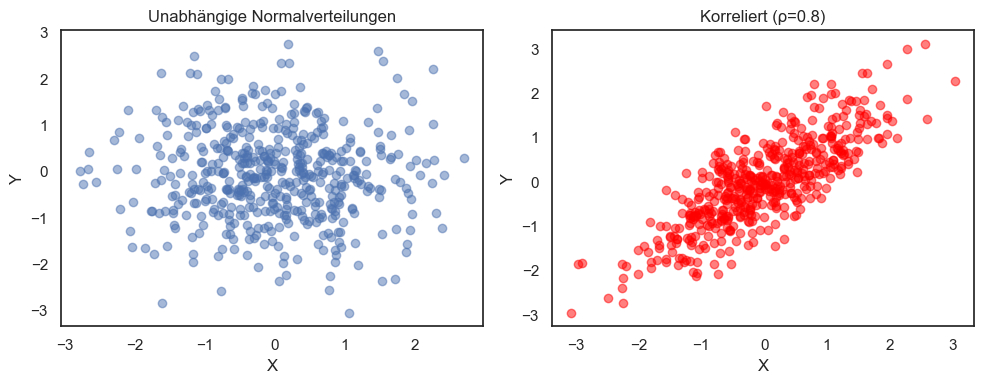

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# 1. Unabhängigkeit vs. Abhängigkeit
np.random.seed(0)
N = 500
X_ind = np.random.normal(0, 1, N)
Y_ind = np.random.normal(0, 1, N)

rho = 0.8
cov = [[1, rho], [rho, 1]]
XY_corr = np.random.multivariate_normal([0,0], cov, N)

fig, axs = plt.subplots(1,2, figsize=(10,4))
axs[0].scatter(X_ind, Y_ind, alpha=0.5)
axs[0].set_title("Unabhängige Normalverteilungen")
axs[0].set_xlabel("X")
axs[0].set_ylabel("Y")

axs[1].scatter(XY_corr[:,0], XY_corr[:,1], alpha=0.5, color="red")
axs[1].set_title("Korreliert (ρ=0.8)")
axs[1].set_xlabel("X")
axs[1].set_ylabel("Y")
plt.tight_layout()
plt.show()


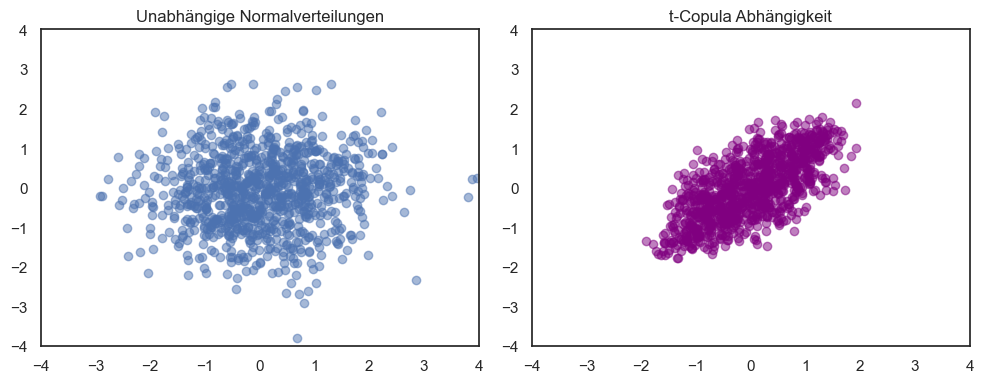

In [102]:
# 2. Copula-Idee: gleiche Ränder, andere Abhängigkeit
from scipy.stats import norm, t

N = 1000
u = np.random.rand(N)
v = np.random.rand(N)

# Unabhängig
X_uni = norm.ppf(u)
Y_uni = norm.ppf(v)

# t-Copula: erzeugt stärkere "Tail Dependence"
df = 3
z = np.random.multivariate_normal([0,0], [[1,0.7],[0.7,1]], N)
X_t = t.cdf(z[:,0], df)
Y_t = t.cdf(z[:,1], df)

X_t = norm.ppf(X_t)
Y_t = norm.ppf(Y_t)

fig, axs = plt.subplots(1,2, figsize=(10,4))
axs[0].scatter(X_uni, Y_uni, alpha=0.5)
axs[0].set_title("Unabhängige Normalverteilungen")
axs[0].set_xlim(-4,4); axs[0].set_ylim(-4,4)

axs[1].scatter(X_t, Y_t, alpha=0.5, color="purple")
axs[1].set_title("t-Copula Abhängigkeit")
axs[1].set_xlim(-4,4); axs[1].set_ylim(-4,4)
plt.tight_layout()
plt.show()


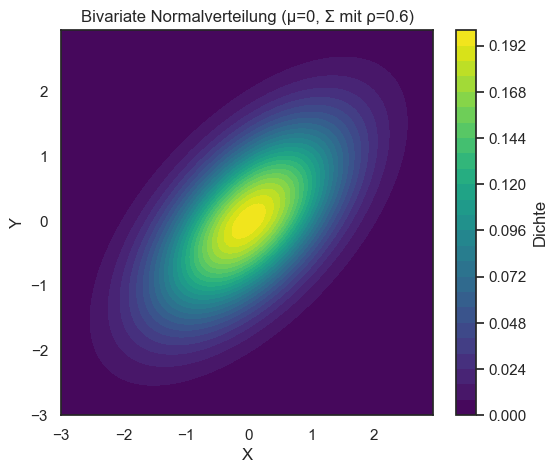

In [103]:
# 3. Multivariate Normalverteilung mit Dichte
mu = np.array([0,0])
cov = np.array([[1,0.6],[0.6,1]])
x, y = np.mgrid[-3:3:.05, -3:3:.05]
pos = np.dstack((x,y))
rv = multivariate_normal(mu, cov)

plt.figure(figsize=(6,5))
plt.contourf(x, y, rv.pdf(pos), cmap="viridis", levels=30)
plt.colorbar(label="Dichte")
plt.title("Bivariate Normalverteilung (μ=0, Σ mit ρ=0.6)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


### 1. Unabhängigkeit vs. Abhängigkeit

- **Linke Punktewolke (unabhängig):** Punkte verteilen sich kreisförmig ohne erkennbare Struktur. Kennt man den Wert von \(X\), weiß man **nichts** über \(Y\).
- **Rechte Punktewolke (abhängig, \(\rho=0.8\)):** Punkte bilden eine elliptische Wolke. Kennt man \(X\), kann man relativ gut \(Y\) abschätzen – das ist die Abhängigkeit.

➡️ **Praxis:** Basis für die Kovarianzmatrix und Korrelation, relevant z.B. in PCA oder Regressionsmodellen.

---

### 2. Copulas

- **Links:** Unabhängigkeit mit Normal-Rändern → runde Wolke.
- **Rechts:** t-Copula mit **Tail Dependence** → in den Rändern (große Werte) treten Punkte gemeinsam auf.  
  Zeigt: Extreme Ereignisse können **gemeinsam** auftreten, obwohl Marginalverteilungen normal sind.

➡️ **Praxis:** Wichtig in der Finanzwelt, da Märkte oft gleichzeitig starke Ausschläge zeigen. Copulas erlauben realistische Modellierung von Abhängigkeiten.

---

### 3. Multivariate Normalverteilung

- Konturen der Dichte (Heatmap) sind **Ellipsen**.
  - \(\rho=0\): Kreise → unabhängige Variablen
  - \(\rho \neq 0\): Ellipsen neigen sich in Richtung der Abhängigkeit

➡️ **Praxis:**
- **PCA:** Analyse der Ellipsenstruktur (Eigenvektoren = Hauptachsen)
- **Gaussian Mixture Models (GMMs):** Kombination vieler Ellipsen zur Modellierung komplexer Daten
- **Anomaly Detection:** Distanz eines Punktes zur Ellipse wird als Mahalanobis-Distanz gemessen


### 8.5 Visualisierung gemeinsamer Verteilungen

In der explorativen Datenanalyse (EDA) ist die **Visualisierung von multivariaten Daten** essenziell, um Zusammenhänge, Abhängigkeiten und Verteilungsformen zu erkennen. Verschiedene Plot-Typen eignen sich dazu, **gemeinsame, marginale und bedingte Verteilungen** darzustellen.

---

#### 1. 2D-Histogramme / Hexbin-Plots

- **Aufbau:**
  - Datenpunkte werden auf einem **Raster** (2D-Gitter) aggregiert.
  - Hexbin-Plots verwenden **hexagonale Zellen**, die die Dichte der Punkte in jedem Bereich visualisieren.
  - Farbintensität entspricht der **Punktdichte**.
- **Interpretation:**
  - Hohe Punktdichte → dunklere Farben
  - Struktur, Cluster und lineare / nichtlineare Zusammenhänge werden sichtbar
- **Praxis:**
  - Analyse von Feature-Korrelationen
  - Identifikation von Clustern oder Bereichen mit Ausreißern

---

#### 2. Heatmaps

- **Aufbau:**
  - Matrix-ähnliche Darstellung von **Zählungen, Korrelationen oder Dichten**.
  - Farbskala repräsentiert Intensität oder Stärke des Zusammenhangs.
- **Interpretation:**
  - Farbverläufe zeigen **starke vs. schwache Abhängigkeiten**.
  - Ideal für **Korrelationsmatrizen** oder 2D-Dichtekarten.
- **Praxis:**
  - Überblick über Zusammenhänge mehrerer Features
  - Unterstützung bei Feature-Selektion und -Engineering

---

#### 3. 3D-Dichteplots

- **Aufbau:**
  - Kontinuierliche **Wahrscheinlichkeitsdichte in 3D** (z. B. für bivariate Normalverteilungen).
  - Achsen: \(X, Y\); Höhe: Dichte \(f_{X,Y}(x,y)\)
- **Interpretation:**
  - Gipfel → Regionen hoher Wahrscheinlichkeitsdichte
  - Form der Oberfläche → Art der Abhängigkeit (linear, nichtlinear, symmetrisch)
- **Praxis:**
  - Visualisierung von Multimodalität
  - Analyse der Ellipsenform bei Normalverteilungen
  - Grundlage für Simulationen und probabilistische Modelle

---

#### 4. Pairplots / Scatterplot-Matrizen

- **Aufbau:**
  - Paarweise Scatterplots aller Features
  - Optional: diagonale Histogramme oder KDEs für Marginalverteilungen
- **Interpretation:**
  - Direkter Vergleich von **Abhängigkeiten zwischen Features**
  - Muster, Cluster oder Ausreißer werden leicht erkennbar
- **Praxis:**
  - EDA bei multivariaten Datensätzen
  - Vorbereitung für PCA, Regression, Klassifikation

---

#### 5. Darstellung marginaler und bedingter Verteilungen

- **Aufbau:**
  - Kombination aus **joint plots** (2D Dichte) und **marginal plots** (1D KDE oder Histogramm)
  - Bedingte Verteilungen können als zusätzliche Linien oder Overlay dargestellt werden
- **Interpretation:**
  - Marginale Plots zeigen die **Einzelverteilungen** der Variablen
  - Bedingte Plots zeigen, wie eine Variable **abhängig von einer anderen** verteilt ist
- **Praxis:**
  - Analyse der Verteilungsform einzelner Features
  - Verständnis von Abhängigkeiten für probabilistische Modelle (z. B. Naive Bayes, Copulas)

---


## Beispielplots - 2D Histogramme und Hexbin plots

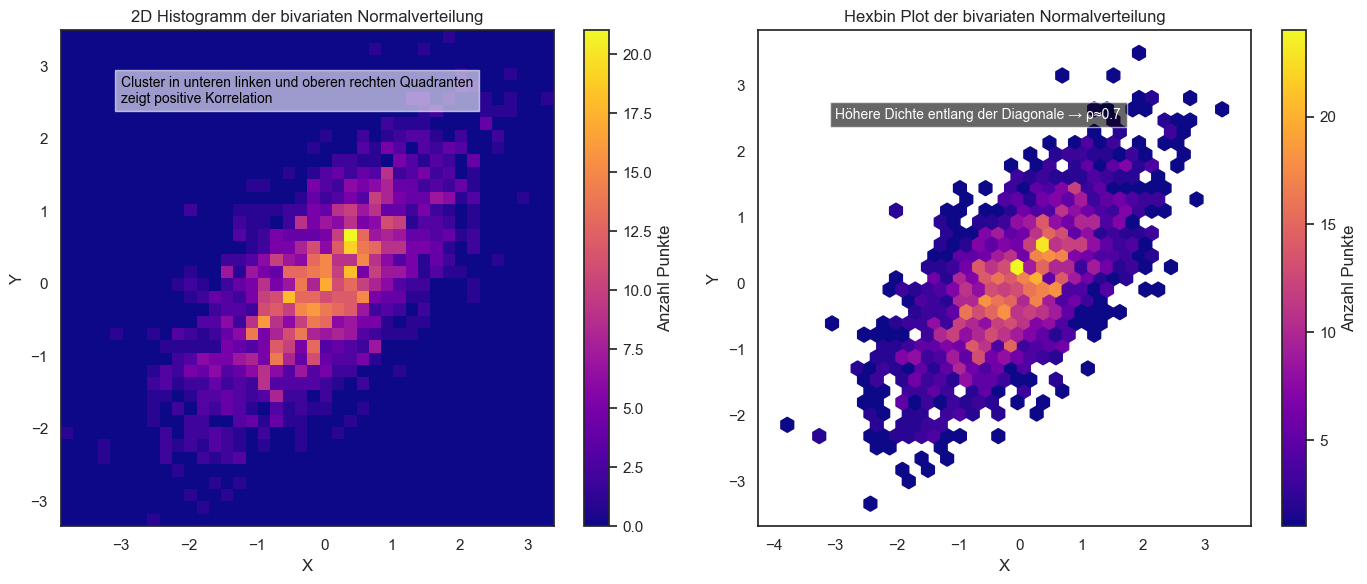

In [104]:
import numpy as np
import matplotlib.pyplot as plt

# Bivariate Normalverteilung simulieren
np.random.seed(42)
mu = [0, 0]
sigma = [[1, 0.7], [0.7, 1]]  # Positive Korrelation
x, y = np.random.multivariate_normal(mu, sigma, 2000).T  # Mehr Punkte für klarere Dichte

plt.figure(figsize=(14,6))

# 1. 2D Histogramm
plt.subplot(1,2,1)
hist = plt.hist2d(x, y, bins=40, cmap='plasma')
plt.colorbar(label='Anzahl Punkte')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D Histogramm der bivariaten Normalverteilung')

# Deutlicher Annotation
plt.text(-3, 2.5, "Cluster in unteren linken und oberen rechten Quadranten\nzeigt positive Korrelation", 
         color='black', fontsize=10, bbox=dict(facecolor='white', alpha=0.6))

# 2. Hexbin Plot
plt.subplot(1,2,2)
hb = plt.hexbin(x, y, gridsize=35, cmap='plasma', mincnt=1)
plt.colorbar(label='Anzahl Punkte')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Hexbin Plot der bivariaten Normalverteilung')

# Annotation sichtbar machen
plt.text(-3, 2.5, "Höhere Dichte entlang der Diagonale → ρ≈0.7", 
         color='white', fontsize=10, bbox=dict(facecolor='black', alpha=0.6))

plt.tight_layout()
plt.show()


In [105]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def interactive_bivariate_plot(rho=0.0):
    np.random.seed(42)
    mu = [0, 0]
    sigma = [[1, rho], [rho, 1]]  # Kovarianzmatrix

    # Stichprobe erzeugen
    x, y = np.random.multivariate_normal(mu, sigma, 2000).T

    plt.figure(figsize=(14,6))

    # 2D Histogramm
    plt.subplot(1,2,1)
    hist = plt.hist2d(x, y, bins=40, cmap='plasma')
    plt.colorbar(label='Anzahl Punkte')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'2D Histogramm (ρ={rho:.2f})')
   # plt.text(-3, 2.5, "Dichte entlang der Diagonale zeigt lineare Abhängigkeit",
   #          color='black', fontsize=10, bbox=dict(facecolor='white', alpha=0.6))

    # Hexbin Plot
    plt.subplot(1,2,2)
    hb = plt.hexbin(x, y, gridsize=35, cmap='plasma', mincnt=1)
    plt.colorbar(label='Anzahl Punkte')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'Hexbin Plot (ρ={rho:.2f})')
   # plt.text(-3, 2.5, "Hellere Hexes entlang der Diagonale → positive Korrelation",
   #          color='white', fontsize=10, bbox=dict(facecolor='black', alpha=0.6))

    plt.tight_layout()
    plt.show()

# Interaktives Widget
interact(interactive_bivariate_plot,
         rho=FloatSlider(value=0.0, min=-0.95, max=0.95, step=0.05, description='ρ'))


interactive(children=(FloatSlider(value=0.0, description='ρ', max=0.95, min=-0.95, step=0.05), Output()), _dom…

<function __main__.interactive_bivariate_plot(rho=0.0)>

## Beispiel Plots für Heatmaps

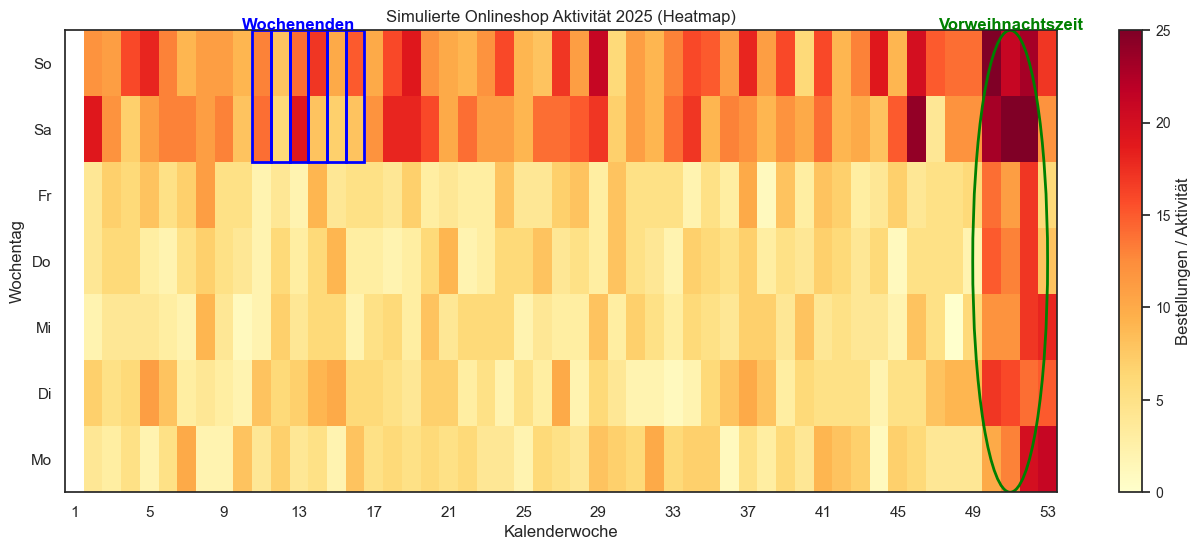

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Rectangle, Ellipse

# Simulation: 1 Jahr
np.random.seed(42)
dates = pd.date_range('2025-01-01', periods=365, freq='D')

# Baseline Aktivität
activity = np.random.poisson(5, size=365)

# Wochenenden (Sa=5, So=6)
weekends = dates.weekday >= 5
activity[weekends] += np.random.poisson(8, size=weekends.sum())  # stärkerer Peak für Cluster

# Vorweihnachtszeit: 01.12. - 24.12.
pre_xmas = (dates >= '2025-12-01') & (dates <= '2025-12-24')
activity[pre_xmas] += np.random.poisson(10, size=pre_xmas.sum())

# DataFrame für Heatmap vorbereiten
df = pd.DataFrame({'date': dates, 'activity': activity})
df['week'] = df['date'].dt.isocalendar().week
df['weekday'] = df['date'].dt.weekday

heatmap = np.full((7, df['week'].max()+1), np.nan)
for _, row in df.iterrows():
    heatmap[row['weekday'], row['week']] = row['activity']

# Plot
fig, ax = plt.subplots(figsize=(16,6))
cmap = plt.cm.YlOrRd
im = ax.imshow(heatmap, aspect='auto', cmap=cmap, origin='lower')

# Achsen
ax.set_yticks(range(7))
ax.set_yticklabels(['Mo','Di','Mi','Do','Fr','Sa','So'])
ax.set_xticks(np.arange(0, df['week'].max()+1, 4))
ax.set_xticklabels(np.arange(1, df['week'].max()+2, 4))
ax.set_xlabel('Kalenderwoche')
ax.set_ylabel('Wochentag')
ax.set_title('Simulierte Onlineshop Aktivität 2025 (Heatmap)')

# Farbskala
cbar = fig.colorbar(im, ax=ax, label='Bestellungen / Aktivität')
cbar.ax.tick_params(labelsize=10)

# Patches für Cluster
# Ellipse für Vorweihnachtszeit (KW 49-52)
ellipse = Ellipse(xy=(50, 3), width=4, height=7, edgecolor='green', facecolor='none', lw=2, label='Vorweihnachtszeit')
ax.add_patch(ellipse)
ax.text(50, 6.5, 'Vorweihnachtszeit', color='green', fontsize=12, fontweight='bold', ha='center')

# Rechtecke für Wochenenden exemplarisch (KW 10-15)
for wk in range(10, 16):
    rect = Rectangle((wk-0.5, 5-0.5), 1, 2, edgecolor='blue', facecolor='none', lw=2)
    ax.add_patch(rect)
ax.text(12, 6.5, 'Wochenenden', color='blue', fontsize=12, fontweight='bold', ha='center')

plt.show()


### 8.5.4 Pairplots / Scatterplot-Matrizen

Ein **Pairplot** (oder Scatterplot-Matrix) ist eine Visualisierungstechnik für **multivariate Datensätze**, die die Beziehungen zwischen allen Variablenpaaren gleichzeitig zeigt. Sie kombiniert Scatterplots für die Paare und oft Histogramme oder Dichteplots für die einzelnen Features auf der Diagonale.

---

#### Aufbau

- **Off-Diagonal**: Scatterplots aller möglichen Variablenpaare $(X_i, X_j)$
- **Diagonal**: Histogramme oder Kernel Density Estimates (KDE) für jedes Feature, um die **Marginalverteilung** zu zeigen
- **Optional**: Farben oder Marker nach Klassen, um Gruppen und Cluster zu unterscheiden

---

#### Interpretation

1. **Lineare oder nichtlineare Abhängigkeiten**  
   - Steigung in Scatterplots zeigt Korrelation
   - Krümmungen oder Muster deuten auf nichtlineare Beziehungen hin
2. **Cluster / Gruppen**  
   - Mehrere Wolken im Scatterplot → mögliche Cluster oder Klassen
3. **Ausreißer**  
   - Einzelne Punkte, die weit außerhalb der Wolke liegen, fallen sofort auf
4. **Marginale Verteilungen**  
   - Histogramme/KDEs zeigen Form, Schiefe und Mehrgipfligkeit der einzelnen Features

---

#### Praxisrelevanz

- **Explorative Datenanalyse (EDA)**: Verständnis der Beziehungen zwischen Variablen
- **Feature Engineering**: Identifikation stark korrelierter Variablen, die redundant sein könnten
- **Vorbereitung für Modelle**: Lineare Regression, Klassifikation, PCA oder Clustering
- **Visualisierung von Gruppen**: Klassenzugehörigkeit oder Cluster kann farblich hervorgehoben werden

---




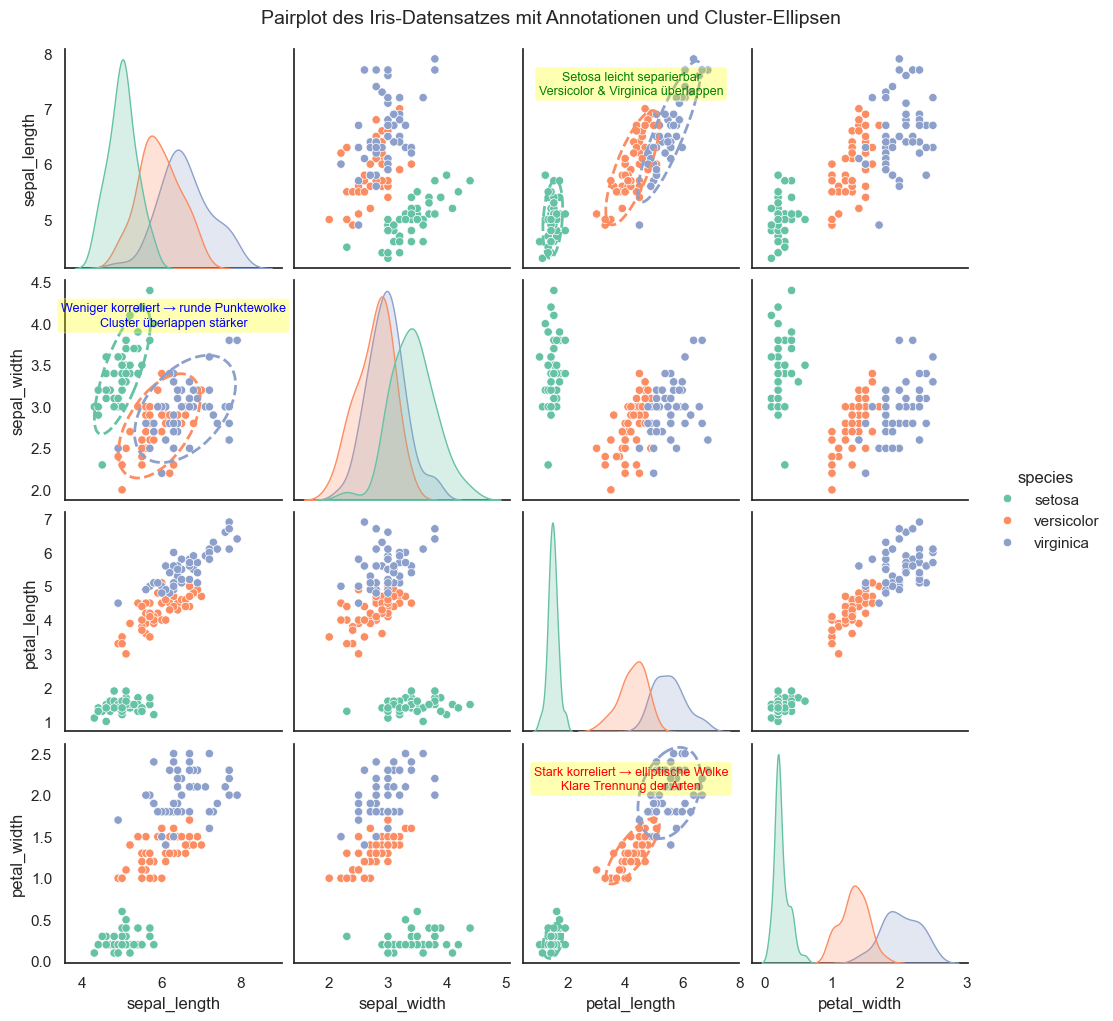

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import numpy as np

# Iris-Datensatz laden
iris = sns.load_dataset("iris")

# Pairplot erstellen
g = sns.pairplot(iris, hue="species", diag_kind="kde", palette="Set2")

# Annotations-Positionsdictionary für gezielte Subplots
annotations = {
    ('petal_length', 'petal_width'): {
        "text": "Stark korreliert → elliptische Wolke\nKlare Trennung der Arten",
        "color": "red"
    },
    ('sepal_length', 'sepal_width'): {
        "text": "Weniger korreliert → runde Punktewolke\nCluster überlappen stärker",
        "color": "blue"
    },
    ('petal_length', 'sepal_length'): {
        "text": "Setosa leicht separierbar\nVersicolor & Virginica überlappen",
        "color": "green"
    }
}

# Subplots annotieren
for i, row_var in enumerate(g.x_vars):
    for j, col_var in enumerate(g.y_vars):
        ax = g.axes[j, i]
        key = (row_var, col_var)
        if key in annotations:
            ann = annotations[key]
            ax.text(0.5, 0.9, ann["text"],
                    transform=ax.transAxes,
                    fontsize=9, color=ann["color"],
                    ha='center', va='top',
                    bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3))
            
            # Ellipsen für Cluster nur in den annotierten Subplots
            for species, color in zip(iris['species'].unique(), ['#66c2a5','#fc8d62','#8da0cb']):
                data = iris[iris['species'] == species][[row_var, col_var]]
                cov = np.cov(data.T)
                vals, vecs = np.linalg.eigh(cov)
                order = vals.argsort()[::-1]
                vals = vals[order]
                vecs = vecs[:, order]
                theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
                # Ellipse: 2 Standardabweichungen
                ell = Ellipse(xy=data.mean().values,
                              width=2*np.sqrt(vals[0])*2, height=2*np.sqrt(vals[1])*2,
                              angle=theta, edgecolor=color, fc='None', lw=2, linestyle='--')
                ax.add_patch(ell)

plt.suptitle("Pairplot des Iris-Datensatzes mit Annotationen und Cluster-Ellipsen", y=1.02, fontsize=14)
plt.show()


#### 5. Darstellung marginaler und bedingter Verteilungen

- **Aufbau:**
  - Kombination aus **Joint Plots** (2D-Dichte) und **Marginal Plots** (1D-KDE oder Histogramm)
  - Bedingte Verteilungen können als zusätzliche Linien oder Overlay dargestellt werden
  - Visualisierung der **gemeinsamen Verteilung** $f_{X,Y}(x,y)$ sowie der **Randverteilungen** $f_X(x)$ und $f_Y(y)$
  - Bedingte Verteilungen $f_{X\mid Y}(x\mid y)$ oder $f_{Y\mid X}(y\mid x)$ lassen sich als **Schnitte durch die 2D-Dichte** darstellen

- **Interpretation:**
  - **Marginale Plots** zeigen die **Einzelverteilungen** der Variablen unabhängig von der anderen
  - **Joint Plot** zeigt die Abhängigkeit zwischen Variablen:
    - Dichtezentren markieren häufige Kombinationen von Werten
    - Streuung oder Form der Ellipsen/Contours gibt Hinweise auf **Korrelation**
  - **Bedingte Verteilungen** verdeutlichen, wie sich die Verteilung einer Variable verändert, wenn die andere festgehalten wird
    - Beispiel: 
    $$
    X \mid Y=y_0 \sim \mathcal{N}\Big(\mu_X + \rho \frac{\sigma_X}{\sigma_Y}(y_0 - \mu_Y),\; \sigma_X^2 (1-\rho^2)\Big)
    $$
    bei bivariater Normalverteilung

- **Praxis:**
  - **EDA / Feature Analysis:** Visualisierung von Zusammenhängen, Cluster-Strukturen oder Ausreißern
  - **Probabilistische Modellierung:** Grundlage für Naive Bayes, Copulas, bivariate Likelihoods
  - **Anomaly Detection:** Punkte außerhalb hoher Dichtebereiche oder außerhalb erwarteter bedingter Verteilungen erkennen
  - **Entscheidung über Feature Engineering:** z. B. Transformationen, Normalisierung oder Auswahl abhängig von Abhängigkeiten


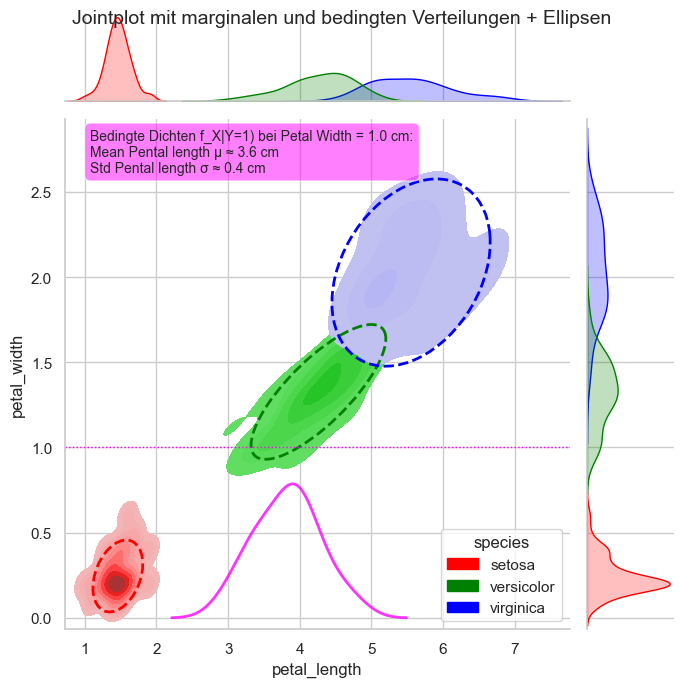

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

# Iris-Datensatz laden
iris = sns.load_dataset("iris")
X = iris["petal_length"].values
Y = iris["petal_width"].values
species = iris["species"].values

# Farben pro Art
palette = {"setosa": "red", "versicolor": "green", "virginica": "blue"}

# Jointplot 2D-KDE
sns.set(style="whitegrid")
g = sns.jointplot(
    data=iris, x="petal_length", y="petal_width",
    hue="species", kind="kde", fill=True,
    palette=palette, height=7
)
ax = g.ax_joint

# Ellipsen um Dichtezentren korrekt ausrichten
for sp, color in palette.items():
    X_sp = iris.loc[iris["species"]==sp, "petal_length"]
    Y_sp = iris.loc[iris["species"]==sp, "petal_width"]
    cov = np.cov(X_sp, Y_sp)
    mean = [X_sp.mean(), Y_sp.mean()]
    eigvals, eigvecs = np.linalg.eigh(cov)
    # Winkel der Ellipse aus dem Eigenvektor der größten Eigenwert
    largest_ev = eigvecs[:, 1]  # Eigenvektor für größten Eigenwert
    angle = np.degrees(np.arctan2(largest_ev[0], largest_ev[1]))
    ell = Ellipse(
        xy=mean,
        width=2*np.sqrt(eigvals[0])*2,
        height=2*np.sqrt(eigvals[1])*2,
        angle=-angle,
        edgecolor=color,
        fc='None',
        lw=2,
        ls='--'
    )
    ax.add_patch(ell)

# Bedingte Verteilungen f_X|Y=y0
y0_values = [1.0, 4.0, 5.5]
colors_cond = ["magenta", "cyan", "orange"]
for y0, c in zip(y0_values, colors_cond):
    mask = np.abs(Y - y0) < 0.2
    if mask.sum() > 1:
        sns.kdeplot(
            X[mask], ax=ax, color=c, lw=2,
            label=f"f_X|Y={y0}", alpha=0.8
        )
        ax.axhline(y=y0, color=c, lw=1, linestyle=':')

   #     # Annotationen oben links
   #     ax.text(0.05, 0.95, "Bedingte Dichten f_X|Y=y0", color="purple", fontsize=10,
   #             transform=ax.transAxes, ha='left', va='top',
   #             bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

# Bedingte Dichte von Petal Length bei Petal Width = 1 cm
y0 = 1.0
species_mask = iris["species"] == "versicolor"
x_vals = iris["petal_length"][species_mask]
y_vals = iris["petal_width"][species_mask]

# Einfaches Fitten einer Gaussfunktion an die Petal Length, wenn Y ≈ y0
subset = iris[np.isclose(iris["petal_width"], y0, atol=0.1)]["petal_length"]
mu_cond = subset.mean()
sigma_cond = subset.std()

# Annotation als Textbox
textstr = f"Bedingte Dichten f_X|Y=1) bei Petal Width = {y0:.1f} cm:\n" \
          f"Mean Pental length μ ≈ {mu_cond:.1f} cm\nStd Pental length σ ≈ {sigma_cond:.1f} cm"

# Textbox einfügen
g.ax_joint.text(0.05, 0.98, textstr, transform=g.ax_joint.transAxes,
                fontsize=10, verticalalignment='top', bbox=dict(boxstyle="round,pad=0.4", 
                                                                fc="magenta", alpha=0.5))

plt.suptitle("Jointplot mit marginalen und bedingten Verteilungen + Ellipsen", fontsize=14)
plt.show()


# 9. Kovarianz & Korrelation

Dieses Kapitel erklärt mathematisch und intuitiv, wie man lineare Zusammenhänge misst, wie die Schätzer aussehen und welche Folgen das für Data Science / ML hat.

---

## 9.1 Kovarianz

**Definition (Population).**  
Für zwei Zufallsvariablen $X,Y$ mit Erwartungswerten $\mu_X,\mu_Y$ gilt
$$
\operatorname{Cov}(X,Y)=\mathbb{E}\big[(X-\mu_X)(Y-\mu_Y)\big].
$$

**Interpretation**
- $\operatorname{Cov}(X,Y)>0$: große Werte von $X$ gehen tendenziell mit großen Werten von $Y$ einher.
- $\operatorname{Cov}(X,Y)<0$: große Werte von $X$ gehen tendenziell mit kleinen Werten von $Y$ einher.
- $\operatorname{Cov}(X,Y)\approx 0$: keine lineare Abhängigkeit (dies ist nicht gleichbedeutend mit Unabhängigkeit).

**Skalenabhängigkeit.**  
Kovarianz hat die Einheit „Einheit von $X$ × Einheit von $Y$“. Ein direkter Vergleich verschiedener Kovarianzen ist daher nur eingeschränkt sinnvoll.

**Schätzer (Stichprobe, unbiased).**  
Für Daten $(x_i,y_i)_{i=1}^n$ mit Stichprobenmittelwerten $\bar x,\bar y$ ist der unbiased Schätzer:
$$
S_{XY}=\frac{1}{n-1}\sum_{i=1}^n (x_i-\bar x)(y_i-\bar y).
$$

**Kurzes numerisches Beispiel.**  
Daten: $X=[1,2,3],\; Y=[2,4,6]$.
- $\bar X=2,\; \bar Y=4$.
- Summe der Produkte:
  $$
  \sum_{i=1}^3 (x_i-\bar x)(y_i-\bar y)=(-1)(-2)+0\cdot0+1\cdot2=4.
  $$
- Population-Cov (mit Division durch $n$):
  $$
  \operatorname{Cov}_{\text{pop}}=\frac{4}{3}\approx 1.333.
  $$
- Stichproben-(unbiased)-Cov (Division durch $n-1$):
  $$
  S_{XY}=\frac{4}{2}=2.
  $$

Hinweis: Hier gilt $Y=2X$ exakt, daher wird später die Pearson-Korrelation $r=1$.

---

## 9.2 Korrelationskoeffizienten

Ziel ist die Skalenunabhängigkeit der Aussage über lineare Zusammenhänge.

### Pearson-Korrelation (linear)
$$
\rho_{X,Y}=\frac{\operatorname{Cov}(X,Y)}{\sigma_X\,\sigma_Y},
$$
wobei $\sigma_X=\sqrt{\operatorname{Var}(X)}$ und $\sigma_Y=\sqrt{\operatorname{Var}(Y)}$. Wertebereich: $-1\le\rho\le1$.

- $\rho=1$: perfekte positive lineare Beziehung.
- $\rho=-1$: perfekte negative lineare Beziehung.
- $\rho=0$: keine lineare Beziehung (kann trotzdem Nichtlinearität vorliegen).

### Spearman-Rangkorrelation
- Berechne Ränge der Werte $x_i\mapsto R(x_i)$, $y_i\mapsto R(y_i)$ und wende Pearson auf die Rangvariablen an.
- Misst monotone Zusammenhänge. Robuster gegenüber Ausreißern und nichtlinearen monotonen Beziehungen.

### Kendall's Tau
- Basierend auf Paarvergleichen (Konkordanz vs. Diskordanz).
- Für $n$ Beobachtungen:
$$
\tau=\frac{C-D}{\binom{n}{2}},
$$
wobei $C$ Anzahl konzordanter Paare und $D$ Anzahl diskordanter Paare ist.

**Praxis:** Verwende Spearman/Kendall bei Ausreißern oder erwarteten nichtlinearen Zusammenhängen.

---

## 9.3 Kovarianzmatrix / Korrelationsmatrix

Für einen Zufallsvektor $\mathbf{X}=(X_1,\dots,X_d)^\top$ ist die Kovarianzmatrix
$$
\Sigma=\operatorname{Cov}(\mathbf{X})=\big[\operatorname{Cov}(X_i,X_j)\big]_{i,j=1}^d.
$$

**Eigenschaften**
- Symmetrisch: $\Sigma=\Sigma^\top$.
- Positiv semidefinit: $v^\top \Sigma v \ge 0$ für alle $v\in\mathbb{R}^d$.
- Diagonalelemente sind Varianzen: $\Sigma_{ii}=\operatorname{Var}(X_i)$.

**Stichproben-Schätzer**
$$
S=\frac{1}{n-1}\sum_{i=1}^n (x_i-\bar x)(x_i-\bar x)^\top,
$$
wobei $x_i$ Spalten-/Zeilenvektoren der Beobachtungen sind (achte auf `rowvar`-Konvention in Implementationen).

**Verwendung in ML**
- **PCA:** Eigenvektoren von $\Sigma$ bestimmen Richtungen maximaler Varianz; Eigenwerte sind die Varianzanteile.
- **Mahalanobis-Distanz:**
$$
d_M(x)=\sqrt{(x-\mu)^\top \Sigma^{-1} (x-\mu)},
$$
skaliert Unterschiede mit $\Sigma^{-1}$.
- **GMM / multivariate Normal:** Likelihoods verwenden $\Sigma$.

**Beispiel (numerisch).**  
Datenmatrix
$$
X=\begin{bmatrix}1 & 2\\ 2 & 4\\ 3 & 6\end{bmatrix},\quad n=3.
$$
- Stichprobenmittel $\bar x=(2,4)^\top$.
- Stichproben-Kovarianzmatrix (unbiased):
$$
S=\frac{1}{n-1}\sum (x_i-\bar x)(x_i-\bar x)^\top
=\begin{bmatrix}1 & 2\\[4pt] 2 & 4\end{bmatrix}.
$$
- Pearson-Korrelation zwischen Spalte 1 und Spalte 2: $r=1$ (perfekte lineare Abhängigkeit).

---

## 9.4 Partielle Korrelation & bedingte Kovarianz

### Partielle Korrelation (dreivariable Formel)
Die partielle Korrelation zwischen $X$ und $Y$ kontrolliert $Z$:
$$
\rho_{XY\mid Z}=\frac{\rho_{XY}-\rho_{XZ}\rho_{YZ}}{\sqrt{(1-\rho_{XZ}^2)(1-\rho_{YZ}^2)}}.
$$
Interpretation: Korrelation der Residuen, nachdem der Effekt von $Z$ herausgerechnet wurde.

### Gesetz der totalen Kovarianz
Für Zufallsvariablen $X,Y$ und Hilfsvariable $Z$ gilt:
$$
\operatorname{Cov}(X,Y)=\mathbb{E}\big[\operatorname{Cov}(X,Y\mid Z)\big]+\operatorname{Cov}\big(\mathbb{E}[X\mid Z],\mathbb{E}[Y\mid Z]\big).
$$

### Bedingte Kovarianz (Matrixform)
Für multivariate Normalverteilung mit Partition
$$
\Sigma=\begin{bmatrix}\Sigma_{XX} & \Sigma_{XZ}\\[2pt]\Sigma_{ZX} & \Sigma_{ZZ}\end{bmatrix}
$$
ist die bedingte Kovarianz von $X$ gegeben $Z=z$:
$$
\operatorname{Cov}(X\mid Z=z)=\Sigma_{XX}-\Sigma_{XZ}\Sigma_{ZZ}^{-1}\Sigma_{ZX}.
$$

Das zeigt, wie sich Kovarianz reduziert, wenn Information über $Z$ vorliegt.

---

## 9.5 Praktische Hinweise, Robustheit, Schätzung

### Zentrieren & Skalieren
- Für PCA: **zuerst zentrieren** ($x_i-\bar x$).  
- Standardisierung (z-Scores) optional; entscheidet, ob PCA Variabilität in absoluten Einheiten (Kovarianz) oder skalenunabhängig (Korrelation) analysiert.

### Stichprobenfehler & Bias
- Verwende $1/(n-1)$ für unbiased Schätzer der Kovarianz.
- Bei kleinem $n$ sind Schätzungen unsicher; erwäge Bootstrap oder Konfidenzintervalle.

### Ausreißer
- Kovarianz und Pearson-Korrelation sind empfindlich gegenüber Ausreißern. Robustere Alternativen: Spearman, Kendall, robuste Kovarianzschätzer (z. B. Minimum Covariance Determinant).

### Multikollinearität in Regression
- **Variance Inflation Factor (VIF):**
$$
\mathrm{VIF}_j=\frac{1}{1-R_j^2},
$$
wobei $R_j^2$ das Bestimmtheitsmaß ist, wenn $X_j$ gegen die anderen Prädiktoren regressiert wird. Regel: $\mathrm{VIF}>5$ (oder $>10$) signalisiert problematische Multikollinearität.

---

## 9.6 Visualisierung & Diagnostik

- **Heatmap** der Korrelationsmatrix für schnellen Überblick.
- **Pairplot / Scattermatrix** zur Untersuchung paarweiser Beziehungen (Farbkodierung nach Klasse erleichtert EDA).
- **Ellipsen (Konfidenzellipsen)** visualisieren Richtung und Ausmaß linearer Streuung (basierend auf Kovarianz).
- **Mahalanobis-Distanz** zur Identifikation multivariater Ausreißer.

---

## 9.7 Checkliste / Entscheidungsbaum (Praxis)

1. Sind Variablen auf vergleichbarer Skala?  
   - Nein → Standardisieren (z. B. für PCA auf Korrelationsmatrix).
2. Gibt es Ausreißer?  
   - Ja → Robuste Maße (Spearman/Kendall, robuste Kovarianz).
3. Ziel: PCA oder Regression?  
   - PCA → zentrieren; ggf. standardisieren.  
   - Regression → VIF prüfen; ggf. Features entfernen/transformieren.
4. Vermutete bedingte Zusammenhänge?  
   - Ja → Partielle Korrelationen oder konditionelle Modelle analysieren.
5. Visualisieren: Heatmap + Pairplot + Ellipsen + Mahalanobis.

---

## 9.8 Implementationshinweise (Kurz)
- NumPy: `np.cov(X, rowvar=False, bias=False)` → Stichproben-Kovarianz mit $1/(n-1)$.  
- Pandas: `df.cov()` und `df.corr(method='pearson'|'spearman')`.  
- VIF: Mit `statsmodels` oder per Regression $R_j^2$ berechnen und $\mathrm{VIF}_j=1/(1-R_j^2)$.

---

## 9.9 Kurzes praktisches Beispiel (Nummerisch)
Siehe Abschnitt 9.3: Für
$$
X=\begin{bmatrix}1 & 2\\ 2 & 4\\ 3 & 6\end{bmatrix}
$$
ergibt der unbiased Schätzer
$$
S=\begin{bmatrix}1 & 2\\[4pt] 2 & 4\end{bmatrix},
$$
und die Pearson-Korrelation zwischen Spalte 1 und Spalte 2 ist $r=1$.

---

### Fazit
Kovarianz und Korrelation sind zentrale Werkzeuge für EDA, Feature-Auswahl, PCA und Modelldiagnostik. Achte systematisch auf Skalen, Ausreißer und Stichprobengröße und kombiniere numerische Maße mit Visualisierungen, bevor du Entscheidungen zu Features triffst.


In [109]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from ipywidgets import interact, IntSlider, FloatSlider, Checkbox, IntText
from scipy import stats
import mplcursors

def plot_corr_demo(rho=0.0, n=50, seed=0, add_outlier=False, standardize=False,
                   scale_x=1.0, scale_y=1.0):
    np.random.seed(int(seed))
    mu = [0,0]
    cov = [[1.0, rho],[rho, 1.0]]
    data = np.random.multivariate_normal(mu, cov, size=int(n))
    x = data[:,0] * scale_x
    y = data[:,1] * scale_y

    if add_outlier:
        x[-1] += 6.0 * scale_x
        y[-1] -= 6.0 * scale_y

    if standardize:
        x = (x - x.mean()) / x.std(ddof=1)
        y = (y - y.mean()) / y.std(ddof=1)

    # Stichproben-Kovarianzmatrix und Kennwerte
    cov_mat = np.cov(x, y, ddof=1)
    cov_xy = cov_mat[0,1]
    pearson_r, _ = stats.pearsonr(x, y)
    spearman_r, _ = stats.spearmanr(x, y)

    # Plot
    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(x, y, s=40, alpha=0.7)
    ax.set_xlabel("X"); ax.set_ylabel("Y")
    ax.set_title(f"Scatter (ρ={rho:.2f}, n={n})")
    ax.set_aspect('equal', 'box')

    # Ellipse (1σ) aus Kovarianz
    eigvals, eigvecs = np.linalg.eigh(cov_mat)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]; eigvecs = eigvecs[:, order]
    angle = np.degrees(np.arctan2(eigvecs[1,0], eigvecs[0,0]))
    width, height = 2*np.sqrt(eigvals)
    ell = Ellipse(xy=(x.mean(), y.mean()), width=width, height=height,
                  angle=angle, edgecolor='red', fc='none', lw=2, ls='--', label='1σ Ellipse')
    ax.add_patch(ell)

    # Textbox: Kennwerte + Kovarianzmatrix
    text = (f"Cov(X,Y) = {cov_xy:.3f}\n"
            f"Pearson r = {pearson_r:.3f}\n"
            f"Spearman ρ = {spearman_r:.3f}\n"
            f"S = [[{cov_mat[0,0]:.3f}, {cov_mat[0,1]:.3f}]\n"
            f"     [{cov_mat[1,0]:.3f}, {cov_mat[1,1]:.3f}]]")
    ax.text(0.02, 0.98, text, transform=ax.transAxes, va='top', ha='left',
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8), family="monospace")

    ax.grid(True, lw=0.3)
    plt.show()

interact(plot_corr_demo,
         rho=FloatSlider(value=0.0, min=-0.95, max=0.95, step=0.01, description='ρ'),
         n=IntSlider(value=50, min=10, max=1000, step=10, description='n'),
         seed=IntText(value=0, description='seed'),
         add_outlier=Checkbox(False, description='Ausreißer'),
         standardize=Checkbox(False, description='Standardisieren'),
         scale_x=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='scale_x'),
         scale_y=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='scale_y'))


interactive(children=(FloatSlider(value=0.0, description='ρ', max=0.95, min=-0.95, step=0.01), IntSlider(value…

<function __main__.plot_corr_demo(rho=0.0, n=50, seed=0, add_outlier=False, standardize=False, scale_x=1.0, scale_y=1.0)>

In [ ]:
%matplotlib inline

# Preamble: Standard-Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Rectangle
from ipywidgets import interact, interactive, widgets, SelectMultiple, Dropdown, FloatSlider, IntSlider, Checkbox
from scipy import stats
from scipy.stats import chi2
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA, PLSRegression
from sklearn.covariance import LedoitWolf, OAS
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LinearRegression
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist, squareform

# optional imports (VIF)
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    import statsmodels.api as sm
    _HAS_STATS = True
except Exception:
    _HAS_STATS = False

sns.set_style("white")


# ---------------------------
# Widget B: Pearson vs Spearman vs Kendall (Robustheit)
# ---------------------------
def widget_B():
    def gen_data(kind, n, seed, noise, outlier):
        rng = np.random.RandomState(int(seed))
        if kind == 'linear':
            x = rng.normal(size=n)
            y = 0.8*x + rng.normal(scale=noise, size=n)
        elif kind == 'quadratic':
            x = rng.uniform(-2, 2, size=n)
            y = (x**2) + rng.normal(scale=noise, size=n)  # non-linear, monotone on [0,inf]
            # shuffle sign to keep monotonic increasing for x>0 but show nonlinearity overall
        elif kind == 'step':
            x = rng.normal(size=n)
            y = np.where(x>0, 1.0, -1.0) + rng.normal(scale=noise, size=n)
        else:
            x = rng.normal(size=n); y = rng.normal(size=n)
        if outlier:
            # add extreme outlier
            x[-1] += 8.0
            y[-1] -= 8.0
        return x, y

    def plot(kind='linear', n=100, seed=0, noise=0.3, outlier=False):
        x, y = gen_data(kind, n, seed, noise, outlier)
        pearson = stats.pearsonr(x, y)[0]
        spearman = stats.spearmanr(x, y)[0]
        kendall = stats.kendalltau(x, y)[0]

        fig, ax = plt.subplots(1,2, figsize=(10,4))
        ax[0].scatter(x, y, alpha=0.7)
        ax[0].set_title(f"{kind} (n={n})")
        ax[0].grid(True)
        # linear fit for visualization
        m, b = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ax[0].plot(xs, m*xs + b)
        ax[1].bar(['Pearson','Spearman','Kendall'], [pearson, spearman, kendall])
        ax[1].set_ylim(-1,1)
        ax[1].set_title("Koeffizienten")
        for i,(k,v) in enumerate({'Pearson':pearson,'Spearman':spearman,'Kendall':kendall}.items()):
            ax[1].text(i, v, f"{v:.3f}", ha='center', va='bottom' if v>=0 else 'top')
        plt.tight_layout()
        plt.show()

    return interact(plot,
                    kind=Dropdown(options=['linear','quadratic','step'], value='linear', description='Relation'),
                    n=IntSlider(value=100, min=20, max=2000, step=10, description='n'),
                    seed=IntSlider(value=0, min=0, max=9999, description='seed'),
                    noise=FloatSlider(value=0.3, min=0.0, max=2.0, step=0.05, description='noise'),
                    outlier=Checkbox(False, description='Ausreißer'))


# ---------------------------
# Widget C: Kovarianz / Korrelations-Heatmap (multivariat)
# ---------------------------
def widget_C():
    df = sns.load_dataset("iris")

    def plot_matrix(feats, mode, thresh):
        if len(feats) < 2:
            print("Wähle mindestens 2 Features")
            return
        data = df[list(feats)].dropna()
        if mode == 'corr':
            M = data.corr()
            title = "Korrelationsmatrix (Pearson)"
        else:
            M = data.cov()
            title = "Kovarianzmatrix"
        fig, ax = plt.subplots(figsize=(6,5))
        sns.heatmap(M, annot=True, fmt=".2f", cmap='vlag', center=0, linewidths=0.5, ax=ax)
        ax.set_title(title)
        # Hervorhebung: Rechteck um große Zellen
        high = (M.abs() >= thresh)
        n = M.shape[0]
        for i in range(n):
            for j in range(n):
                if high.iat[i,j] and i!=j:
                    ax.add_patch(Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=1.2))
        plt.show()

    feats_init = list(df.columns[:-1])
    return interact(plot_matrix,
             feats=SelectMultiple(options=feats_init, value=feats_init, description='Features'),
             mode=Dropdown(options=['corr','cov'], value='corr', description='Mode'),
             thresh=FloatSlider(value=0.7, min=0.0, max=1.5, step=0.05, description='Threshold'))


# ---------------------------
# Widget D: PCA-Demo (Scree, PC-Scatter, Loadings)
# ---------------------------
def widget_D():
    # Beispiel-Datensatz
    df = sns.load_dataset("iris")


    
    def pca_demo_6plots_hover(feats=['sepal_length','sepal_width','petal_length','petal_width'],
                            standardize=True, n_components=4,
                            ev_pair=('sepal_length','sepal_width')):
        X = df[list(feats)].values
        
        if standardize:
            Xs = StandardScaler().fit_transform(X)
            matrix = np.corrcoef(X.T)
            matrix_title = "Korrelationsmatrix (standardisiert)"
        else:
            Xs = X - X.mean(axis=0)
            matrix = np.cov(X.T)
            matrix_title = "Kovarianzmatrix (nicht standardisiert)"
        
        cov_mat = np.cov(Xs.T)
        eigvals, eigvecs = np.linalg.eigh(cov_mat)
        order = eigvals.argsort()[::-1]
        eigvals = eigvals[order]
        eigvecs = eigvecs[:, order]
        
        pcs = Xs @ eigvecs[:, :n_components]
        ev_ratio = eigvals[:n_components] / eigvals.sum()
        
        loadings = eigvecs[:, :2] * np.sqrt(eigvals[:2])
        
        fig, axs = plt.subplots(3, 2, figsize=(14,14))
        axs = axs.flatten()
        
        # 1. Scree Plot
        axs[0].bar(np.arange(1,len(ev_ratio)+1), ev_ratio*100)
        axs[0].set_xlabel("Hauptkomponente")
        axs[0].set_ylabel("% erklärte Varianz")
        axs[0].set_title("Scree-Plot")
        for i, v in enumerate(ev_ratio*100):
            axs[0].text(i+1, v+0.5, f"{v:.1f}%", ha='center')
        
        # 2. Scatter PC1 vs PC2
        scatter = axs[1].scatter(pcs[:,0], pcs[:,1],
                                c=pd.Categorical(df['species']).codes,
                                cmap="Set2", edgecolor="k")
        axs[1].set_xlabel(f"PC1 ({ev_ratio[0]*100:.1f}% Varianz)")
        axs[1].set_ylabel(f"PC2 ({ev_ratio[1]*100:.1f}% Varianz)")
        axs[1].set_title("PC1 vs PC2")
        legend1 = axs[1].legend(*scatter.legend_elements(), title="Species")
        axs[1].add_artist(legend1)
        axs[1].grid(True, linestyle="--", alpha=0.5)
        
        # 3. Scatter PC2 vs PC3
        if n_components >=3:
            scatter2 = axs[2].scatter(pcs[:,1], pcs[:,2],
                                    c=pd.Categorical(df['species']).codes,
                                    cmap="Set2", edgecolor="k")
            axs[2].set_xlabel(f"PC2 ({ev_ratio[1]*100:.1f}% Varianz)")
            axs[2].set_ylabel(f"PC3 ({ev_ratio[2]*100:.1f}% Varianz)")
            axs[2].set_title("PC2 vs PC3")
            legend2 = axs[2].legend(*scatter2.legend_elements(), title="Species")
            axs[2].add_artist(legend2)
            axs[2].grid(True, linestyle="--", alpha=0.5)
        else:
            axs[2].axis('off')
        
        # 4. Loadings PC1/PC2
        ind = np.arange(len(feats))
        width = 0.35
        axs[3].bar(ind - width/2, loadings[:,0], width, label="PC1")
        axs[3].bar(ind + width/2, loadings[:,1], width, label="PC2")
        axs[3].set_xticks(ind)
        axs[3].set_xticklabels(feats, rotation=45)
        axs[3].set_ylabel("Loading")
        axs[3].set_title("Loadings auf PC1 und PC2")
        axs[3].legend()
        
        # 5. Kovarianz-/Korrelationsmatrix
        sns.heatmap(matrix, annot=True, fmt=".2f", cmap="vlag", center=0,
                    xticklabels=feats, yticklabels=feats, ax=axs[4])
        axs[4].set_title(matrix_title)
        
        # 6. Eigenvektoren der ausgewählten Features + Unit Circle + Hover + Legenden
        axs[5].set_title(f"Eigenvektoren von {ev_pair[0]} & {ev_pair[1]} (Unit Circle Loadings)")
        idx = [feats.index(ev_pair[0]), feats.index(ev_pair[1])]
        cov2 = matrix[np.ix_(idx, idx)]
        eigvals2, eigvecs2 = np.linalg.eigh(cov2)
        order2 = eigvals2.argsort()[::-1]
        eigvals2 = eigvals2[order2]
        eigvecs2 = eigvecs2[:, order2]
        
        scatter3 = axs[5].scatter(Xs[:,idx[0]], Xs[:,idx[1]],
                                c=pd.Categorical(df['species']).codes,
                                cmap="Set2", edgecolor='k', label="Datenpunkte")
        
        origin = np.zeros(2)
        for i in range(2):
            vec = eigvecs2[:,i] * np.sqrt(eigvals2[i])*2
            axs[5].arrow(origin[0], origin[1], vec[0], vec[1],
                        color='red', width=0.02, head_width=0.15, label=f"EV{i+1}")
            axs[5].text(vec[0]*1.05, vec[1]*1.05, f"λ={eigvals2[i]:.2f}", color='red')
        
        circle = plt.Circle((0,0), 1, color='blue', fill=False, linestyle='--', lw=1.5, label="Unit Circle Loadings")
        axs[5].add_patch(circle)
        
        axs[5].set_xlabel(ev_pair[0])
        axs[5].set_ylabel(ev_pair[1])
        axs[5].grid(True, linestyle="--", alpha=0.5)
        
        # Legenden zusammenfassen
        handles, labels = axs[5].get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        axs[5].legend(by_label.values(), by_label.keys(), loc='upper right')
        
        # Hover Info
        cursor = mplcursors.cursor(scatter3, hover=True)
        @cursor.connect("add")
        def on_add(sel):
            i = sel.target.index
            sel.annotation.set(text=f"Species: {df['species'].iloc[i]}\n{ev_pair[0]}={Xs[i,idx[0]]:.2f}\n{ev_pair[1]}={Xs[i,idx[1]]:.2f}")
        
        plt.tight_layout()
        plt.show()

    # Interaktives Widget
    interact(pca_demo_6plots_hover,
            feats=SelectMultiple(options=list(df.columns[:-1]),
                                value=list(df.columns[:-1]),
                                description="Features"),
            standardize=Checkbox(value=True, description="Standardisieren"),
            n_components=IntSlider(value=4, min=2, max=4, step=1,
                                    description="n PCs"),
            ev_pair=SelectMultiple(options=list(df.columns[:-1]),
                                    value=['sepal_length','sepal_width'],
                                    description="Feature-Paar"))


# ---------------------------
# Widget E: Mahalanobis & Konfidenzellipse / Anomalie-Erkennung
# ---------------------------
def widget_E():
    df = sns.load_dataset("iris")
    features = list(df.columns[:-1])

    def mahalanobis_demo(feats, thresh_p=0.975):
        data = df[list(feats)].values
        mu = data.mean(axis=0)
        cov = np.cov(data, rowvar=False)
        inv_cov = np.linalg.inv(cov)

        # Mahalanobis-Distanz berechnen
        diff = data - mu
        d2 = np.einsum("ij,jk,ik->i", diff, inv_cov, diff)  # quadrierte Distanz
        d = np.sqrt(d2)

        # Threshold aus Chi²-Verteilung
        thresh = np.sqrt(chi2.ppf(thresh_p, df=data.shape[1]))
        outliers = np.where(d > thresh)[0]

        # Plot
        if data.shape[1] == 2:
            plt.figure(figsize=(6,6))
            plt.scatter(data[:,0], data[:,1], c="gray", alpha=0.6, label="Daten")
            plt.scatter(data[outliers,0], data[outliers,1], c="red", label="Ausreißer")

            # Konfidenzellipse
            eigvals, eigvecs = np.linalg.eigh(cov)
            order = eigvals.argsort()[::-1]
            eigvals, eigvecs = eigvals[order], eigvecs[:,order]

            angle = np.degrees(np.arctan2(*eigvecs[:,0][::-1]))
            width, height = 2*np.sqrt(eigvals) * thresh
            from matplotlib.patches import Ellipse
            ell = Ellipse(xy=mu, width=width, height=height, angle=angle,
                        edgecolor="blue", fc="None", lw=2, ls="--")
            plt.gca().add_patch(ell)

            plt.xlabel(feats[0]); plt.ylabel(feats[1])
            plt.title(f"Mahalanobis-Distanz\nThreshold (p={thresh_p:.3f})")
            plt.legend()
            plt.show()
        else:
            plt.figure()
            plt.hist(d, bins=30, color="gray", alpha=0.7)
            plt.axvline(thresh, color="red", ls="--", label=f"Schwelle={thresh:.2f}")
            plt.xlabel("Mahalanobis-Distanz")
            plt.ylabel("Häufigkeit")
            plt.title(f"Verteilung der Distanzen (p={thresh_p:.3f})")
            plt.legend()
            plt.show()

        print("Ausreißer-Indizes:", outliers.tolist())

    # Interaktives Widget
    E_widget = interact(
        mahalanobis_demo,
        feats=SelectMultiple(options=features, value=features[:2], description='Features'),
        thresh_p=FloatSlider(
            value=0.975,
            min=0.90,
            max=0.999,
            step=0.005,
            description='p'
        )
    )


# ---------------------------
# Widget F: Partielle Korrelation (3 Variablen)
# ---------------------------
def widget_F():
    df = sns.load_dataset("iris")
    cols = list(df.columns[:-1])

    def partial_corr(xvar, yvar, zvar):
        X = df[[xvar, yvar, zvar]].dropna()
        lr = LinearRegression()
        # Residual X|Z
        lr.fit(X[[zvar]], X[[xvar]])
        rx = X[xvar] - lr.predict(X[[zvar]]).ravel()
        # Residual Y|Z
        lr.fit(X[[zvar]], X[[yvar]])
        ry = X[yvar] - lr.predict(X[[zvar]]).ravel()
        r_partial = stats.pearsonr(rx, ry)[0]
        fig, ax = plt.subplots(1,2, figsize=(10,4))
        ax[0].scatter(X[zvar], X[xvar], alpha=0.6); ax[0].set_title(f"{xvar} ~ {zvar}")
        ax[1].scatter(X[zvar], X[yvar], alpha=0.6); ax[1].set_title(f"{yvar} ~ {zvar}")
        plt.tight_layout()
        plt.show()
        plt.figure(figsize=(5,4))
        plt.scatter(rx, ry, alpha=0.7)
        plt.title(f"Residuen: partielle Korrelation = {r_partial:.3f}")
        plt.xlabel(f"{xvar} resid"); plt.ylabel(f"{yvar} resid")
        plt.grid(True); plt.show()
        print("Partielle Korrelation (Residuen):", r_partial)
    return interact(partial_corr,
                    xvar=Dropdown(options=cols, value=cols[0], description='X'),
                    yvar=Dropdown(options=cols, value=cols[1], description='Y'),
                    zvar=Dropdown(options=cols, value=cols[2], description='Z'))


# ---------------------------
# Widget G: Bootstrap CI für Pearson-r
# ---------------------------
def widget_G():
    def bootstrap_r(n=1000, seed=0, n_boot=1000):
        rng = np.random.RandomState(int(seed))
        # synthetic correlated data
        x = rng.normal(size=n)
        y = 0.6*x + rng.normal(scale=1.0, size=n)
        r0 = stats.pearsonr(x, y)[0]
        boots = []
        for _ in range(int(n_boot)):
            idx = rng.randint(0, n, n)
            boots.append(stats.pearsonr(x[idx], y[idx])[0])
        boots = np.array(boots)
        ci = np.percentile(boots, [2.5, 97.5])
        plt.figure(figsize=(6,3))
        plt.hist(boots, bins=40, density=True)
        plt.axvline(r0, lw=2)
        plt.axvline(ci[0], ls='--'); plt.axvline(ci[1], ls='--')
        plt.title(f"Bootstrap r (orig={r0:.3f}), 95% CI = [{ci[0]:.3f}, {ci[1]:.3f}]")
        plt.show()
        print("orig r:", r0, "95% CI:", ci)
    return interact(bootstrap_r,
                    n=IntSlider(100, min=20, max=2000, step=10, description='n'),
                    seed=IntSlider(0, min=0, max=9999, description='seed'),
                    n_boot=IntSlider(1000, min=100, max=5000, step=100, description='n_boot'))


# ---------------------------
# Widget H: VIF (Variance Inflation Factor)
# ---------------------------
def widget_H():
    df = sns.load_dataset("iris")
    features = list(df.columns[:-1])
    def compute_vif(feats):
        X = df[list(feats)].dropna()
        Xc = X.copy()
        if _HAS_STATS:
            Xc_const = sm.add_constant(Xc)
            vif_data = []
            for i in range(1, Xc_const.shape[1]):
                vif_data.append((Xc.columns[i-1], variance_inflation_factor(Xc_const.values, i)))
            res = pd.DataFrame(vif_data, columns=['feature','VIF']).set_index('feature')
            display(res)
        else:
            # fallback: R^2 based via sklearn
            res = []
            for i, col in enumerate(Xc.columns):
                y = Xc[col].values
                Xothers = Xc.drop(columns=[col]).values
                lr = LinearRegression().fit(Xothers, y)
                R2 = lr.score(Xothers, y)
                vif = 1.0 / (1.0 - R2) if R2 < 1 else np.inf
                res.append((col, vif))
            res = pd.DataFrame(res, columns=['feature','VIF']).set_index('feature')
            display(res)
    return interact(compute_vif, feats=SelectMultiple(options=features, value=features, description='Features'))


# ---------------------------
# Widget I: Canonical Correlation Analysis (CCA)
# ---------------------------
def widget_I():
    df = sns.load_dataset("iris")
    numeric = list(df.columns[:-1])
    def cca_demo(group1, group2, standardize=True, n_comp=1):
        if not group1 or not group2:
            print("Wähle mindestens 1 Feature in beiden Gruppen")
            return
        X = df[list(group1)].values
        Y = df[list(group2)].values
        if standardize:
            X = StandardScaler().fit_transform(X); Y = StandardScaler().fit_transform(Y)
        n_comp = min(int(n_comp), min(X.shape[1], Y.shape[1]))
        cca = CCA(n_components=n_comp)
        U, V = cca.fit_transform(X, Y)
        corrs = [np.corrcoef(U[:,i], V[:,i])[0,1] for i in range(n_comp)]
        plt.figure(figsize=(6,4))
        plt.scatter(U[:,0], V[:,0], alpha=0.7)
        plt.xlabel('U1'); plt.ylabel('V1'); plt.title(f'CCA: corr(U1,V1)={corrs[0]:.3f}')
        plt.grid(True); plt.show()
        print("Kanonische Korrelationen:", np.round(corrs,3))
    return interact(cca_demo,
                    group1=SelectMultiple(options=numeric, value=numeric[:2], description='Gruppe 1'),
                    group2=SelectMultiple(options=numeric, value=numeric[2:], description='Gruppe 2'),
                    standardize=Checkbox(True, description='Standardisieren'),
                    n_comp=IntSlider(1, min=1, max=3, step=1, description='n_comp'))


# ---------------------------
# Widget J: PLS Regression Demo
# ---------------------------
def widget_J():
    df = sns.load_dataset("iris")
    Xcols = list(df.columns[:-1])
    y_options = ['petal_length','petal_width']  # choose a continuous target
    def pls_demo(feats, target, n_components=2, standardize=True):
        X = df[list(feats)].values
        y = df[target].values
        if standardize:
            Xs = StandardScaler().fit_transform(X)
        else:
            Xs = X - X.mean(axis=0)
        pls = PLSRegression(n_components=min(n_components, Xs.shape[1]))
        pls.fit(Xs, y)
        ypred = pls.predict(Xs).ravel()
        fig, ax = plt.subplots(1,2, figsize=(10,4))
        ax[0].scatter(y, ypred, alpha=0.7); ax[0].plot([y.min(), y.max()], [y.min(), y.max()])
        ax[0].set_title("Predicted vs Actual")
        # loadings
        load = pls.x_weights_
        for i,feat in enumerate(feats):
            ax[1].bar(i, np.linalg.norm(load[i,:]))
        ax[1].set_xticks(np.arange(len(feats))); ax[1].set_xticklabels(feats, rotation=45)
        ax[1].set_title("Ladungen (Normen)")
        plt.tight_layout(); plt.show()
        print("R^2 (train):", np.round(pls.score(Xs,y),3))
    return interact(pls_demo,
                    feats=SelectMultiple(options=Xcols, value=Xcols, description='Features'),
                    target=Dropdown(options=y_options, value=y_options[0], description='Target'),
                    n_components=IntSlider(2, min=1, max=min(len(Xcols),5), step=1, description='n_comp'),
                    standardize=Checkbox(True, description='Standardisieren'))


# ---------------------------
# Widget K: Hierarchische Clusteranalyse + Dendrogramm
# ---------------------------
def widget_K():
    df = sns.load_dataset("iris")
    feats = list(df.columns[:-1])
    def cluster_demo(selected_feats, metric='correlation', linkage='average'):
        X = df[list(selected_feats)].dropna()
        # distance between features using 1-abs(corr)
        corr = X.corr().abs()
        dist = 1 - corr
        linkage_mat = hierarchy.linkage(squareform(dist), method=linkage)
        fig = plt.figure(figsize=(8,4))
        dn = hierarchy.dendrogram(linkage_mat, labels=selected_feats)
        plt.title("Feature Dendrogram")
        plt.show()
        # reordered heatmap
        order = dn['ivl']
        M = X[order].corr()
        plt.figure(figsize=(6,5))
        sns.heatmap(M, annot=True, fmt=".2f", cmap='vlag', center=0)
        plt.title("Korrelations-Heatmap (reordered)")
        plt.show()
    return interact(cluster_demo,
                    selected_feats=SelectMultiple(options=feats, value=feats, description='Features'),
                    metric=Dropdown(options=['correlation','euclidean'], value='correlation', description='metric'),
                    linkage=Dropdown(options=['single','complete','average','ward'], value='average', description='linkage'))


# ---------------------------
# Widget L: Autocorrelation / Cross-correlation (Zeitreihe)
# ---------------------------
def widget_L():
    # synthetic AR(1) example
    def generate_ar(n, phi, sigma, seed):
        rng = np.random.RandomState(int(seed))
        x = np.zeros(n)
        for t in range(1, n):
            x[t] = phi * x[t-1] + rng.normal(scale=sigma)
        return x

    def acf(x, nlags):
        x = x - x.mean()
        r = np.correlate(x, x, mode='full')[len(x)-1:]
        r = r / r[0]
        return r[:nlags+1]

    def ac_demo(n=200, phi=0.6, sigma=1.0, maxlag=40, seed=0):
        x = generate_ar(n, phi, sigma, seed)
        ac = acf(x, maxlag)
        lags = np.arange(len(ac))

        plt.figure(figsize=(8,3))
        markerline, stemlines, baseline = plt.stem(lags, ac)   # kein use_line_collection
        plt.setp(markerline, 'markerfacecolor', 'C0')
        plt.setp(stemlines, 'color', 'C0')
        plt.axhline(0, color='k', lw=0.6)

        # ungefähr 95%-Konfidenzband für ACF ≈ ±1.96/sqrt(n)
        conf = 1.96 / np.sqrt(n)
        plt.axhline(conf, ls='--', color='gray', lw=0.8)
        plt.axhline(-conf, ls='--', color='gray', lw=0.8)

        plt.xlabel('Lag')
        plt.ylabel('ACF')
        plt.title(f'Autokorrelation (n={n}, phi={phi:.2f})')
        plt.ylim(-1,1)
        plt.grid(True)
        plt.show()

    interact(ac_demo,
            n=IntSlider(value=200, min=50, max=2000, step=10, description='n'),
            phi=FloatSlider(value=0.6, min=-0.99, max=0.99, step=0.01, description='phi'),
            sigma=FloatSlider(value=1.0, min=0.01, max=3.0, step=0.01, description='sigma'),
            maxlag=IntSlider(value=40, min=1, max=200, step=1, description='maxlag'),
            seed=IntSlider(value=0, min=0, max=9999, description='seed'))


# ---------------------------
# Widget M: Mutual Information vs Pearson
# ---------------------------
def widget_M():
    df = sns.load_dataset("iris")
    feats = list(df.columns[:-1])
    def mi_demo(xcol, ycol, bins=10):
        X = df[xcol].values.reshape(-1,1)
        y = df[ycol].values
        pear = stats.pearsonr(df[xcol], df[ycol])[0]
        spear = stats.spearmanr(df[xcol], df[ycol])[0]
        # mutual information continuous estimator
        mi = mutual_info_regression(X, y, discrete_features=False)
        plt.figure(figsize=(5,4))
        plt.scatter(df[xcol], df[ycol], alpha=0.7)
        plt.title(f"Pearson={pear:.3f}, Spearman={spear:.3f}, MI={mi[0]:.3f}")
        plt.xlabel(xcol); plt.ylabel(ycol); plt.grid(True); plt.show()
    return interact(mi_demo,
                    xcol=Dropdown(options=feats, value=feats[0], description='X'),
                    ycol=Dropdown(options=feats, value=feats[1], description='Y'),
                    bins=IntSlider(10, min=2, max=50, description='bins'))


# ---------------------------
# Widget N: Shrinkage Covariance (Ledoit-Wolf / OAS)
# ---------------------------
def widget_N():
    df = sns.load_dataset("iris")
    feats = list(df.columns[:-1])
    def shrinkage_demo(feats_sel, method='sample'):
        X = df[list(feats_sel)].values
        sample = np.cov(X, rowvar=False)
        if method == 'ledoit-wolf':
            lw = LedoitWolf().fit(X)
            S = lw.covariance_
        elif method == 'oas':
            oas = OAS().fit(X)
            S = oas.covariance_
        else:
            S = sample
        fig, ax = plt.subplots(1,2, figsize=(10,4))
        sns.heatmap(sample, ax=ax[0], annot=False); ax[0].set_title('Sample Cov')
        sns.heatmap(S, ax=ax[1], annot=False); ax[1].set_title(method)
        plt.show()
        print("Condition numbers: sample=", np.linalg.cond(sample), method+"=", np.linalg.cond(S))
    return interact(shrinkage_demo,
                    feats_sel=SelectMultiple(options=feats, value=feats, description='Features'),
                    method=Dropdown(options=['sample','ledoit-wolf','oas'], value='sample', description='method'))


# ---------------------------
# Widget O: Randomization (Permutation) Test für Korrelation
# ---------------------------
def widget_O():
    df = sns.load_dataset("iris")
    feats = list(df.columns[:-1])
    def perm_test(xcol, ycol, n_perm=1000, seed=0):
        rng = np.random.RandomState(int(seed))
        x = df[xcol].values
        y = df[ycol].values
        obs = stats.pearsonr(x,y)[0]
        perms = []
        for _ in range(int(n_perm)):
            y_perm = rng.permutation(y)
            perms.append(stats.pearsonr(x, y_perm)[0])
        perms = np.array(perms)
        pval = (np.sum(np.abs(perms) >= np.abs(obs)) + 1) / (n_perm + 1)
        plt.figure(figsize=(6,3))
        plt.hist(perms, bins=40, density=True)
        plt.axvline(obs, color='k', lw=2)
        plt.title(f"perm test: obs r={obs:.3f}, p={pval:.3f}")
        plt.show()
        print("p-value (two-sided):", pval)
    return interact(perm_test,
                    xcol=Dropdown(options=feats, value=feats[0], description='X'),
                    ycol=Dropdown(options=feats, value=feats[1], description='Y'),
                    n_perm=IntSlider(1000, min=100, max=5000, step=100, description='n_perm'),
                    seed=IntSlider(0, min=0, max=9999, description='seed'))


# ---------------------------
# Widget P: Copula-Demo (Gaussian + t)
# ---------------------------
def widget_P():
    def gaussian_copula(rho, n, seed, marg):
        rng = np.random.RandomState(int(seed))
        cov = np.array([[1.0, rho],[rho,1.0]])
        U = stats.multivariate_normal(mean=[0,0], cov=cov).rvs(size=n, random_state=rng)
        U = stats.norm.cdf(U)  # copula -> uniform marginals
        if marg == 'normal':
            X = stats.norm.ppf(U)
        elif marg == 'exp':
            X = stats.expon.ppf(U)
        else:
            X = stats.t.ppf(U, df=3)
        return X[:,0], X[:,1]

    def copula_demo(kind='gaussian', rho=0.5, n=500, seed=0, marg='normal'):
        if kind == 'gaussian':
            x, y = gaussian_copula(rho, n, seed, marg)
        else:
            # t-copula via multivariate t: sample normal, scale by sqrt(chi2/df)
            rng = np.random.RandomState(int(seed))
            df_t = 4
            cov = np.array([[1.0, rho],[rho,1.0]])
            z = stats.multivariate_normal(mean=[0,0], cov=cov).rvs(size=n, random_state=rng)
            g = np.sqrt(df_t / stats.chi2.rvs(df_t, size=n, random_state=rng))
            t_samples = z * g[:,None]
            U = stats.t.cdf(t_samples, df=df_t)
            if marg == 'normal':
                x = stats.norm.ppf(U[:,0]); y = stats.norm.ppf(U[:,1])
            else:
                x = stats.expon.ppf(U[:,0]); y = stats.expon.ppf(U[:,1])
        plt.figure(figsize=(5,5))
        plt.scatter(x, y, alpha=0.6)
        plt.title(f"{kind} copula (rho={rho:.2f})")
        plt.grid(True); plt.show()
    return interact(copula_demo,
                    kind=Dropdown(options=['gaussian','t'], value='gaussian', description='copula'),
                    rho=FloatSlider(0.5, min=-0.99, max=0.99, step=0.01, description='rho'),
                    n=IntSlider(500, min=50, max=5000, step=50, description='n'),
                    seed=IntSlider(0, min=0, max=9999, description='seed'),
                    marg=Dropdown(options=['normal','exp','t3'], value='normal', description='marginal'))

# ---------------------------
# Instantiate widgets (call the functions)
# ---------------------------
# Uncomment the ones you want to show immediately in the notebook.

B_widget = widget_B()
#C_widget = widget_C()
# D_widget = widget_D()
# E_widget = widget_E()
# F_widget = widget_F()
# G_widget = widget_G()
# H_widget = widget_H()
# I_widget = widget_I()
# J_widget = widget_J()
# K_widget = widget_K()
# L_widget = widget_L()
# M_widget = widget_M()
# N_widget = widget_N()
# O_widget = widget_O()
# P_widget = widget_P()


interactive(children=(Dropdown(description='Relation', options=('linear', 'quadratic', 'step'), value='linear'…

## Widget B — Pearson vs Spearman vs Kendall

- **Inputs**: Beziehungstyp (linear, quadratisch, stufenförmig), `add_outlier`.
- **Beobachte**:
  - Linear: Alle Koeffizienten nahe 1.
  - Quadratisch: Pearson ≈ 0 (weil nichtlinear), Spearman/Kendall > 0 (monoton erkannt).
  - Ausreißer: Pearson bricht stärker ein, Spearman/Kendall stabiler.
- **Takeaway**:  
  Pearson misst lineare Abhängigkeit, Spearman/Kendall monotone Strukturen und sind robuster.

---

In [111]:
C_widget = widget_C()

interactive(children=(SelectMultiple(description='Features', index=(0, 1, 2, 3), options=('sepal_length', 'sep…

## Widget C — Kovarianz / Korrelations-Heatmap

- **Inputs**: Feature-Auswahl, `mode = cov/corr`, `thresh`.
- **Beobachte**:
  - Umschalten cov ↔ corr: Unterschied zwischen skalenabhängigen Werten und standardisierten Korrelationen.
  - Entferne ein Feature: Heatmap-Struktur ändert sich → Basis für PCA-Übung.
  - Threshold erhöhen: Hohe Korrelationen werden sichtbar.
- **Takeaway**:  
  Korrelationsmatrizen zeigen Redundanzen. Schwellenwerte helfen, Multikollinearität zu erkennen.

---

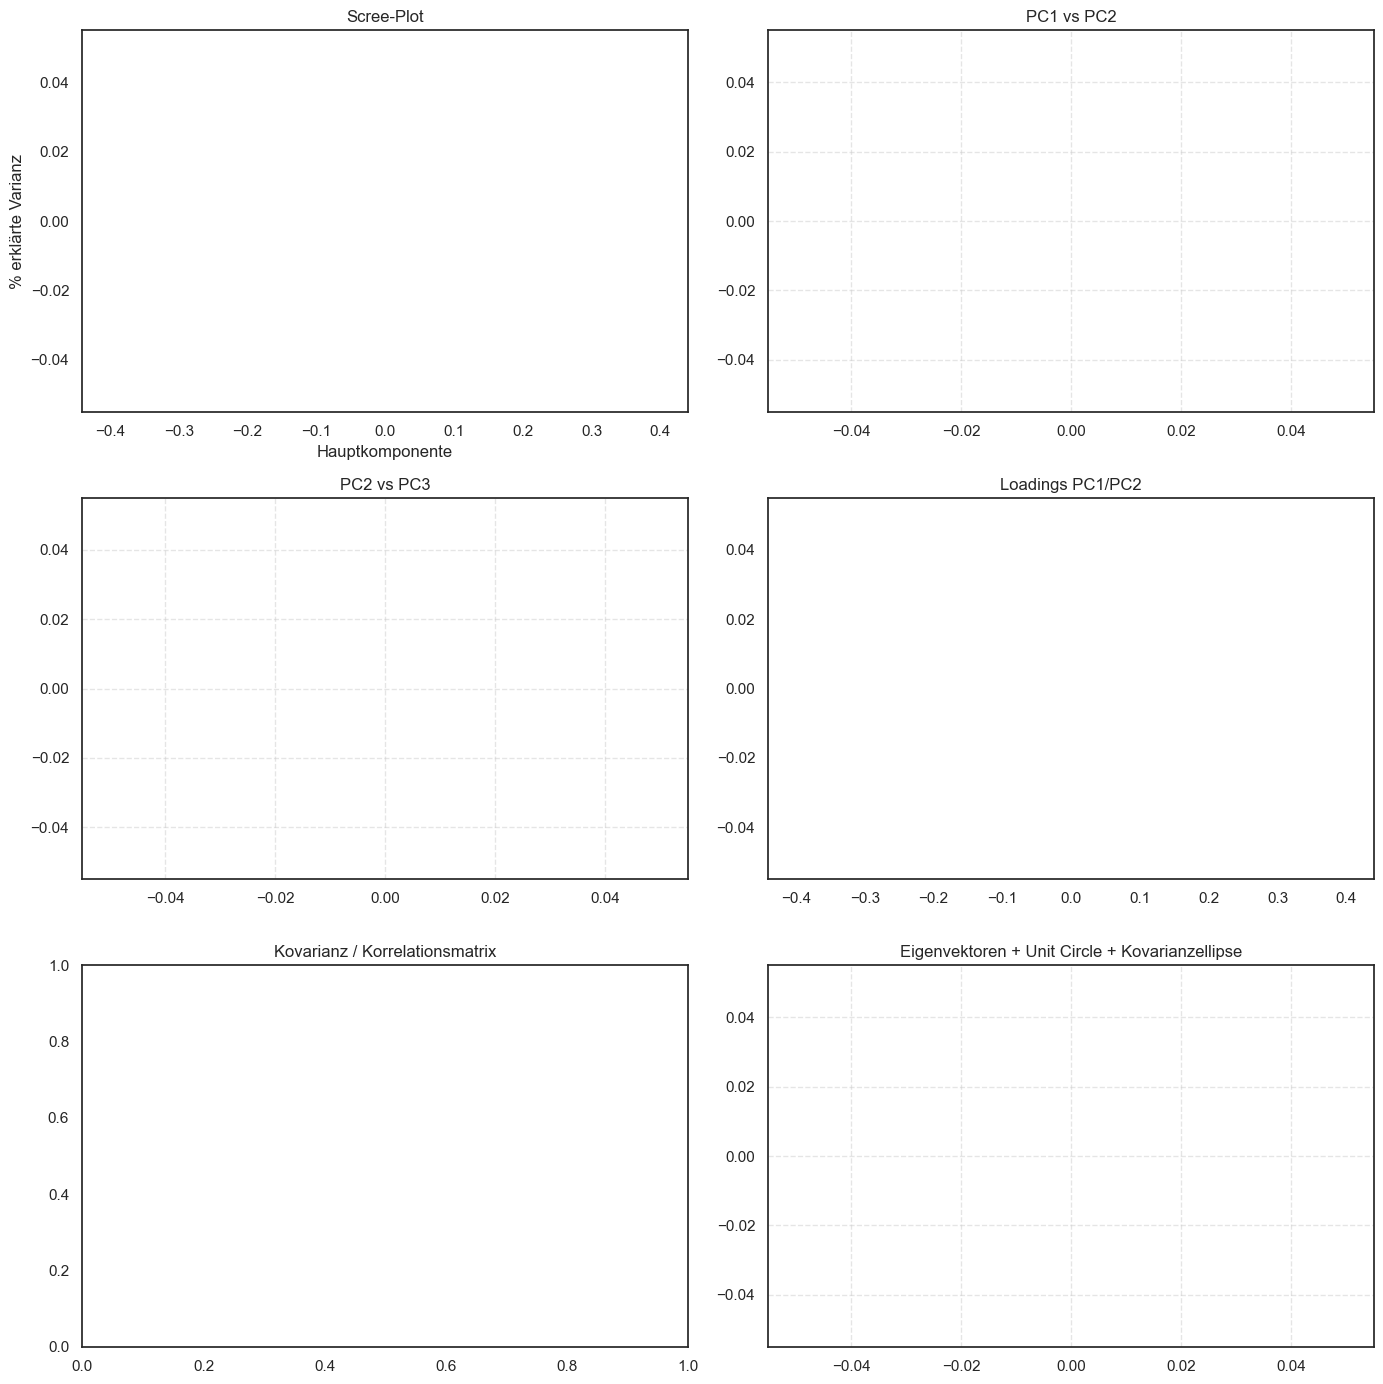

interactive(children=(SelectMultiple(description='Features', index=(0, 1, 2, 3), options=('sepal_length', 'sep…

In [112]:
D_widget = widget_D()

## Widget D — PCA Demo

### Idee
PCA (Principal Component Analysis) ist eine Dimensionsreduktionstechnik, die die Richtung(en) maximaler Varianz in den Daten findet.  
Sie basiert auf der Eigenzerlegung der **Kovarianzmatrix** (oder Korrelationsmatrix, falls standardisiert).

- **Eigenvektoren** = Richtungen (Principal Components, PCs)  
- **Eigenwerte** = Varianz entlang dieser Richtungen  

---

### Inputs im Widget
- **Features**: Auswahl, auf welche Variablen PCA angewendet wird.  
- **Standardize**: Checkbox (ja/nein).  
  - *Nein*: PCA basiert auf Kovarianzmatrix. Feature mit großer Skala dominiert.  
  - *Ja*: PCA basiert auf Korrelationsmatrix. Beiträge sind vergleichbar.  
- **n PCs**: Anzahl der Hauptkomponenten, die analysiert werden.

---

### Outputs
1. **Scree-Plot**  
   - Balken = Varianzanteil jeder PC (%).  
   - Interpretation: Steiler Abfall → wenige PCs reichen aus.  
   - Flach → keine dominante Richtung, viele PCs nötig.  

2. **Scatterplot (PC1 vs PC2)**  
   - Punkte = Projektionen der Originaldaten.  
   - Farbcode = Klassenlabel (z. B. Species im Iris-Datensatz).  
   - Beobachtung:  
     - Ohne Standardisierung: Clustering verzerrt, ein Feature bestimmt PC1.  
     - Mit Standardisierung: Cluster sichtbarer, Struktur der Daten besser erkennbar.  

3. **Loadings (Eigenvektoren)**  
   - Zeigen, wie stark jedes Feature auf PC1/PC2 lädt.  
   - Ohne Standardisierung: große Skala ⇒ große Ladungen.  
   - Mit Standardisierung: Ladungen zeigen *Zusammenhänge*, nicht Einheiten.  

---

### Didaktische Beobachtungen
- **Ohne Standardisierung**:  
  PCA ist sensitiv gegenüber unterschiedlichen Skalen. Ein dominantes Feature kann die Struktur „verdecken“.  
  → Effekt: PC1 ≈ „größte Varianz“ Feature, Scree-Plot oft stark einseitig.  

- **Mit Standardisierung**:  
  Alle Features haben gleiche Varianz. PCA arbeitet effektiv auf der Korrelationsmatrix.  
  → Effekt: PCs spiegeln Muster und Korrelationen wider. Klassen (z. B. Iris-Arten) werden im Scatterplot klarer getrennt.  

---

### Takeaway
- PCA maximiert Varianz, aber Varianz hängt von der Skala ab.  
- **Standardisierung ist fast immer Pflicht**, wenn Features in unterschiedlichen Einheiten gemessen sind.  
- Scree-Plot hilft zu entscheiden, wie viele PCs „genug“ sind.  
- Loadings machen sichtbar, welche Variablen zu den PCs beitragen.


In [113]:
E_widget = widget_E()

interactive(children=(SelectMultiple(description='Features', index=(0, 1), options=('sepal_length', 'sepal_wid…

## Widget E — Mahalanobis-Distanz & Konfidenzellipse

- **Inputs**: Feature-Auswahl, Signifikanzschwelle.
- **Beobachte**:
  - Ellipse markiert 95%- oder 99%-Konfidenzbereich.
  - Punkte außerhalb: potenzielle Ausreißer.
  - Schwelle variieren: mehr/weniger Punkte als „Anomalien“ markiert.
- **Takeaway**:  
  Mahalanobis berücksichtigt Varianz **und** Korrelation. Ellipsen visualisieren multivariate Normalbereiche.

---

In [114]:
F_widget = widget_F()

interactive(children=(Dropdown(description='X', options=('sepal_length', 'sepal_width', 'petal_length', 'petal…

## Widget F — Partielle Korrelation

- **Inputs**: Auswahl X, Y, Z.
- **Beobachte**:
  - Pearson(X,Y) oft hoch.  
  - Partielle Korrelation(X,Y|Z) geringer, wenn Z die Beziehung erklärt.  
  - Residuen-Scatter zeigt „direkten“ Zusammenhang ohne Z.
- **Takeaway**:  
  Partielle Korrelation = Abhängigkeit nach Herausrechnen eines dritten Faktors.

---

In [115]:
G_widget = widget_G()

interactive(children=(IntSlider(value=100, description='n', max=2000, min=20, step=10), IntSlider(value=0, des…

## Widget G — Bootstrap CI für Pearson-r

- **Inputs**: `n_boot`, `seed`.
- **Beobachte**:
  - Histogramm der Bootstraps → Schätzunsicherheit von r.  
  - Kleine n: breite Streuung.  
  - Große n: enge Verteilung um wahres r.
- **Takeaway**:  
  Bootstrap zeigt Konfidenzintervalle ohne Normalverteilungsannahme.

---

In [116]:
H_widget = widget_H()

interactive(children=(SelectMultiple(description='Features', index=(0, 1, 2, 3), options=('sepal_length', 'sep…

## Widget H — VIF (Variance Inflation Factor)

- **Inputs**: Feature-Set.
- **Beobachte**:
  - Starke Multikollinearität → hohe VIF-Werte (>5 oder >10).  
  - Entfernt man ein stark korreliertes Feature, sinken VIFs.
- **Takeaway**:  
  VIF ist Standarddiagnostik für Multikollinearität in Regressionsmodellen.

---

In [117]:
I_widget = widget_I()

interactive(children=(SelectMultiple(description='Gruppe 1', index=(0, 1), options=('sepal_length', 'sepal_wid…

## Widget I — Canonical Correlation Analysis (CCA)

- **Inputs**: Zwei Featuregruppen, Standardisierung.
- **Beobachte**:
  - Scatter der kanonischen Variablen → maximale lineare Abhängigkeit.  
  - Korrelationswerte: CCA-Koeffizienten.
- **Takeaway**:  
  CCA findet verborgene Dimensionen, die zwei Variablensets maximal koppeln.

---

In [118]:
J_Widget = widget_J()

interactive(children=(SelectMultiple(description='Features', index=(0, 1, 2, 3), options=('sepal_length', 'sep…

## Widget J — Partial Least Squares (PLS)

- **Inputs**: Features, Zielvariable, n Komponenten.
- **Beobachte**:
  - Varianzaufteilung ähnlich PCA, aber an Ziel angepasst.  
  - Loadings zeigen, welche Features wichtig für Vorhersage sind.
- **Takeaway**:  
  PLS kombiniert Dimensionsreduktion mit Prognoseorientierung.

---

In [119]:
K_widget = widget_K()

interactive(children=(SelectMultiple(description='Features', index=(0, 1, 2, 3), options=('sepal_length', 'sep…

## Widget K — Hierarchisches Clustering + Dendrogramm

- **Inputs**: Feature-Auswahl, Metrik, Linkage.
- **Beobachte**:
  - Heatmap + Dendrogramm zeigen Feature-Gruppen.  
  - Ähnliche Variablen „hängen“ zusammen.
- **Takeaway**:  
  Clustering enthüllt Gruppenstruktur in Korrelationsmatrizen.

---


In [120]:
L_widget = widget_L()

interactive(children=(IntSlider(value=200, description='n', max=2000, min=50, step=10), FloatSlider(value=0.6,…

## Widget L — Autokorrelation / Cross-Korrelation

- **Inputs**: Zeitreihe, Lag.
- **Beobachte**:
  - ACF zeigt periodische Strukturen oder Trend.  
  - CCF (zweier Reihen) → mögliche Zeitverschiebung.
- **Takeaway**:  
  Zeitliche Abhängigkeiten werden über Korrelationen in Lags sichtbar.

---

In [121]:
M_widget = widget_M()

interactive(children=(Dropdown(description='X', options=('sepal_length', 'sepal_width', 'petal_length', 'petal…

## Widget M — Mutual Information vs Pearson

- **Inputs**: Feature-Paar, n Bins.
- **Beobachte**:
  - Pearson ≈ 0 bei nichtlinearen Mustern.  
  - Mutual Information > 0 → Abhängigkeit vorhanden.
- **Takeaway**:  
  MI erkennt Abhängigkeit auch ohne linearen Zusammenhang.

---

In [122]:
N_widget = widget_N()

interactive(children=(SelectMultiple(description='Features', index=(0, 1, 2, 3), options=('sepal_length', 'sep…

## Widget N — Shrinkage-Kovarianz (Ledoit-Wolf)

- **Inputs**: n (Samples), p (Dimension), Methode (Sample vs LW vs OAS).
- **Beobachte**:
  - Klassische Kovarianz instabil bei n < p.  
  - Shrinkage-Matrizen besser konditioniert, stabilere Heatmaps.
- **Takeaway**:  
  Shrinkage verbessert Kovarianzschätzungen in hochdimensionalen Settings.

---

In [123]:
O_widget = widget_O()

interactive(children=(Dropdown(description='X', options=('sepal_length', 'sepal_width', 'petal_length', 'petal…

## Widget O — Randomization Test für Korrelation

- **Inputs**: Feature-Paar, n Permutationen.
- **Beobachte**:
  - Histogramm permutierter r.  
  - Beobachtetes r als Linie → p-Wert direkt sichtbar.
- **Takeaway**:  
  Permutationstest = verteilungsfreier Signifikanztest.

---

In [124]:
P_widget = widget_P()

interactive(children=(Dropdown(description='copula', options=('gaussian', 't'), value='gaussian'), FloatSlider…

## Widget P — Copula-Demo

- **Inputs**: Copula-Typ (Gaussian, t, Clayton, Gumbel), Parameter.
- **Beobachte**:
  - Unterschiedliche Abhängigkeitsstrukturen, z. B. Tail-Dependence.  
  - Scatter im Copula-Raum verdeutlicht Randverteilungen vs Abhängigkeit.
- **Takeaway**:  
  Copulas trennen Randverteilungen von Abhängigkeitsstruktur. Mehr als nur lineare Korrelation.

---